# 🏀 NBA Game Predictor — Monte Carlo Simulation

This notebook builds an end-to-end NBA game prediction pipeline:
1. **Feature Engineering** — rolling stats, Elo ratings, home/away splits
2. **Base Models** — XGBoost for spread + win probability
3. **Monte Carlo Engine** — simulate score distributions → win%, spread, totals
4. **Evaluation** — accuracy, AUC, calibration, Brier score
5. **Prediction Interface** — predict any upcoming game with confidence intervals

In [34]:
# ── Installs (run once) ────────────────────────────────────────────────────────
%pip install xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from tqdm import tqdm
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, roc_auc_score, brier_score_loss,
    mean_absolute_error, confusion_matrix, classification_report
)
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('dark_background')
ACCENT = '#00D4FF'
print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Load Data

In [36]:
train_df = pd.read_csv('nba_train.csv')
test_df  = pd.read_csv('nba_test.csv')
ref_df   = pd.read_csv('nba_team_reference.csv')
ref_df['game_date'] = pd.to_datetime(ref_df['game_date'])

print(f'Training set:   {train_df.shape[0]:,} games x {train_df.shape[1]} features')
print(f'Test set:       {test_df.shape[0]:,} games x {test_df.shape[1]} features')
print(f'Team reference: {ref_df.shape[0]:,} rows')
print(f'Ref columns:    {ref_df.columns.tolist()}')

n_train   = len(train_df)
n_test    = len(test_df)
train_ref = ref_df.iloc[:n_train].reset_index(drop=True)
test_ref  = ref_df.iloc[n_train:n_train + n_test].reset_index(drop=True)

print(f'\nTrain reference: {len(train_ref):,} rows')
print(f'Test  reference: {len(test_ref):,} rows')
print(f'Test date range: {test_ref["game_date"].min().date()} → {test_ref["game_date"].max().date()}')

Training set:   7,575 games x 28 features
Test set:       1,515 games x 28 features
Team reference: 9,090 rows
Ref columns:    ['game_id', 'game_date', 'season_year', 'team_abbreviation_home', 'team_abbreviation_away', 'team_id_home', 'team_id_away', 'pts_home', 'pts_away', 'home_win']

Train reference: 7,575 rows
Test  reference: 1,515 rows
Test date range: 2024-03-14 → 2025-06-19


In [37]:
# ── Quick data audit ───────────────────────────────────────────────────────────
print('=== TRAIN COLUMNS ===')
print(train_df.columns.tolist())
print('\n=== TRAIN HEAD ===')
train_df.head(3)

=== TRAIN COLUMNS ===
['pts_home_roll10', 'fg_pct_home_roll10', 'fg3_pct_home_roll10', 'ft_pct_home_roll10', 'reb_home_roll10', 'ast_home_roll10', 'stl_home_roll10', 'blk_home_roll10', 'tov_home_roll10', 'plus_minus_home_roll10', 'pts_away_roll10', 'fg_pct_away_roll10', 'fg3_pct_away_roll10', 'ft_pct_away_roll10', 'reb_away_roll10', 'ast_away_roll10', 'stl_away_roll10', 'blk_away_roll10', 'tov_away_roll10', 'plus_minus_away_roll10', 'home_win_rate_roll10', 'team_id_home_enc', 'team_id_away_enc', 'season_type_Pre Season', 'season_type_Regular Season', 'is_home_favored', 'home_win', 'sample_weight']

=== TRAIN HEAD ===


,pts_home_roll10,fg_pct_home_roll10,fg3_pct_home_roll10,ft_pct_home_roll10,reb_home_roll10,ast_home_roll10,stl_home_roll10,blk_home_roll10,tov_home_roll10,plus_minus_home_roll10,...,tov_away_roll10,plus_minus_away_roll10,home_win_rate_roll10,team_id_home_enc,team_id_away_enc,season_type_Pre Season,season_type_Regular Season,is_home_favored,home_win,sample_weight
0,-0.218122,0.261712,-1.409793,0.721870,-1.199411,-0.673802,-0.783088,-0.921902,1.044582,-1.233961,...,0.989153,-1.878033,-1.069277,-0.611520,-1.664984,-0.137637,0.313195,0.0,1,0.122456
1,-2.472030,-2.214453,-0.551383,1.361335,1.908596,-2.863252,-2.202512,1.467723,1.720249,-0.297177,...,-1.825879,-2.147635,-0.291438,-0.030805,1.585447,-0.137637,0.313195,0.0,0,0.122456
2,-0.617548,2.619964,0.978826,-2.378819,-1.558027,0.098945,0.068567,-0.921902,1.668275,0.065047,...,-1.423731,-1.015304,-1.069277,1.479053,0.192405,-0.137637,0.313195,0.0,1,0.122456


In [38]:
print('=== REF HEAD ===')
ref_df.head(3)

=== REF HEAD ===


,game_id,game_date,season_year,team_abbreviation_home,team_abbreviation_away,team_id_home,team_id_away,pts_home,pts_away,home_win
0,21700598,2018-01-08,2018,LAC,ATL,1610612746,1610612737,108.0,107.0,1
1,21700606,2018-01-10,2018,BKN,DET,1610612751,1610612765,80.0,114.0,0
2,21700620,2018-01-12,2018,WAS,ORL,1610612764,1610612753,125.0,119.0,1


## 2. Feature Engineering

We build differential features (home − away) for all numeric columns, rolling averages, Elo ratings, and rest-days.

In [39]:
# ──────────────────────────────────────────────────────────────────────────────
# ELO RATING ENGINE
# ──────────────────────────────────────────────────────────────────────────────
class EloRater:
    """Maintains live Elo ratings for all NBA teams."""

    def __init__(self, k=20, home_adv=100, initial=1500):
        self.k = k
        self.home_adv = home_adv
        self.initial = initial
        self.ratings = {}

    def get(self, team):
        return self.ratings.get(team, self.initial)

    def expected(self, r_a, r_b):
        return 1 / (1 + 10 ** ((r_b - r_a) / 400))

    def update(self, home_team, away_team, home_win):
        r_h = self.get(home_team) + self.home_adv
        r_a = self.get(away_team)
        e_h = self.expected(r_h, r_a)
        e_a = 1 - e_h
        delta_h = self.k * (home_win - e_h)
        self.ratings[home_team] = self.get(home_team) + delta_h
        self.ratings[away_team] = self.get(away_team) - delta_h
        return e_h  # expected home win prob BEFORE update

    def snapshot(self):
        return self.ratings.copy()


# ──────────────────────────────────────────────────────────────────────────────
# FEATURE BUILDER
# ──────────────────────────────────────────────────────────────────────────────
def build_features(df, ref, elo: EloRater, windows=(5, 10), fit_elo=True):
    """
    Merge game df with ref_df, compute:
      - differential features (home - away)
      - rolling averages per team
      - Elo gap
      - days rest

    Parameters
    ----------
    df      : game-level DataFrame (train_df or test_df)
    ref     : matching slice of ref_df
    elo     : EloRater instance (modified in-place when fit_elo=True)
    windows : rolling window sizes
    fit_elo : whether to update Elo ratings from this data
    """
    df = df.copy().reset_index(drop=True)
    ref = ref.copy().reset_index(drop=True)

    # ── Detect key columns ────────────────────────────────────────────────────
    # Adapt these to your actual column names
    cols = df.columns.tolist()

    home_score_col = next((c for c in cols if 'home' in c.lower() and 'score' in c.lower()), None)
    away_score_col = next((c for c in cols if 'away' in c.lower() and 'score' in c.lower()), None)
    # Only pick string/object columns for team name detection
    str_cols = df.select_dtypes(include='object').columns.tolist()
    home_team_col  = next((c for c in str_cols if 'home' in c.lower() and 'team' in c.lower()), None)
    away_team_col  = next((c for c in str_cols if 'away' in c.lower() and 'team' in c.lower()), None)
    target_col     = next((c for c in cols if c.lower() in ('home_win', 'result', 'target', 'label')), None)
    date_col       = next((c for c in ref.columns if 'date' in c.lower()), None)

    print(f'  home_score={home_score_col}, away_score={away_score_col}')
    print(f'  home_team={home_team_col},  away_team={away_team_col}')
    print(f'  target={target_col}, date={date_col}')

    # ── Target: home team won ─────────────────────────────────────────────────
    if target_col:
        y = df[target_col].astype(int)
    elif home_score_col and away_score_col:
        y = (df[home_score_col] > df[away_score_col]).astype(int)
    else:
        y = None
        print('  ⚠️  Could not auto-detect target column — set manually')

    # ── Spread (home − away points) ───────────────────────────────────────────
    if home_score_col and away_score_col:
        spread = df[home_score_col] - df[away_score_col]
        total  = df[home_score_col] + df[away_score_col]
    else:
        spread = total = None

    # ── Numeric feature differentials ─────────────────────────────────────────
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    # Remove score / target cols from features
    exclude = {home_score_col, away_score_col, target_col} - {None}
    feat_cols = [c for c in num_cols if c not in exclude]

    X = df[feat_cols].copy()

    # ── Elo features ──────────────────────────────────────────────────────────
    elo_home, elo_away, elo_exp = [], [], []
    if home_team_col and away_team_col:
        for i, row in df.iterrows():
            ht, at = row[home_team_col], row[away_team_col]
            eh = elo.get(ht)
            ea = elo.get(at)
            exp = elo.expected(eh + elo.home_adv, ea)
            elo_home.append(eh)
            elo_away.append(ea)
            elo_exp.append(exp)
            if fit_elo and y is not None:
                elo.update(ht, at, y.iloc[i])
        X['elo_home'] = elo_home
        X['elo_away'] = elo_away
        X['elo_gap']  = np.array(elo_home) - np.array(elo_away)
        X['elo_exp_home'] = elo_exp

    # ── Fill missing values ───────────────────────────────────────────────────
    X = X.fillna(X.median(numeric_only=True))

    return X, y, spread, total


print('✅ Feature engineering functions defined')

✅ Feature engineering functions defined


In [40]:
# ── Build features ─────────────────────────────────────────────────────────────
elo = EloRater(k=20, home_adv=100)

print('Building TRAIN features...')
X_train, y_train, spread_train, total_train = build_features(train_df, train_ref, elo, fit_elo=True)

print('\nBuilding TEST features...')
X_test, y_test, spread_test, total_test = build_features(test_df, test_ref, elo, fit_elo=False)

print(f'\nX_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Train win rate: {y_train.mean():.3f}')
if y_test is not None:
    print(f'Test  win rate: {y_test.mean():.3f}')

Building TRAIN features...
  home_score=None, away_score=None
  home_team=None,  away_team=None
  target=home_win, date=game_date

Building TEST features...
  home_score=None, away_score=None
  home_team=None,  away_team=None
  target=home_win, date=game_date

X_train: (7575, 27), X_test: (1515, 27)
Train win rate: 0.563
Test  win rate: 0.544


## 3. Base Models
- **Classifier** → P(home win)
- **Regressor** → predicted spread (home − away points)

In [41]:
# ── Scale features ─────────────────────────────────────────────────────────────
scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

# ── Win probability classifier ────────────────────────────────────────────────
clf = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', use_label_encoder=False,
    random_state=42
)
clf.fit(Xs_train, y_train, eval_set=[(Xs_test, y_test)], verbose=False)

# Calibrate probabilities (Platt scaling)
# cv='prefit' removed in newer sklearn — use cv=5 cross-val calibration
clf_cal = CalibratedClassifierCV(
    XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', use_label_encoder=False, random_state=42
    ),
    cv=5, method='sigmoid'
)
clf_cal.fit(Xs_train, y_train)

# ── Spread regressor ──────────────────────────────────────────────────────────
reg = None
if spread_train is not None:
    reg = XGBRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42
    )
    reg.fit(Xs_train, spread_train, eval_set=[(Xs_test, spread_test)], verbose=False)
    print(f'Spread MAE (train): {mean_absolute_error(spread_train, reg.predict(Xs_train)):.2f} pts')
    print(f'Spread MAE (test):  {mean_absolute_error(spread_test,  reg.predict(Xs_test)):.2f} pts')

print('\n✅ Models trained')


✅ Models trained


In [42]:
# ── Base model evaluation ──────────────────────────────────────────────────────
if y_test is not None:
    probs = clf_cal.predict_proba(Xs_test)[:, 1]
    preds = (probs >= 0.5).astype(int)

    acc   = accuracy_score(y_test, preds)
    auc   = roc_auc_score(y_test, probs)
    brier = brier_score_loss(y_test, probs)

    print(f'Accuracy : {acc:.4f}  ({acc*100:.1f}%)')
    print(f'ROC AUC  : {auc:.4f}')
    print(f'Brier    : {brier:.4f}  (lower = better, 0.25 = random)')
    print()
    print(classification_report(y_test, preds, target_names=['Away Win', 'Home Win']))

Accuracy : 0.6396  (64.0%)
ROC AUC  : 0.6868
Brier    : 0.2273  (lower = better, 0.25 = random)

              precision    recall  f1-score   support

    Away Win       0.65      0.44      0.53       691
    Home Win       0.63      0.80      0.71       824

    accuracy                           0.64      1515
   macro avg       0.64      0.62      0.62      1515
weighted avg       0.64      0.64      0.63      1515



## 4. Monte Carlo Simulation Engine

For each game we:
1. Get the model's predicted spread μ and win probability p.
2. Fit a score distribution from historical residuals.
3. Sample N simulated game scores.
4. Aggregate to get win%, spread CI, total CI.

In [43]:
# ──────────────────────────────────────────────────────────────────────────────
# MONTE CARLO ENGINE
# ──────────────────────────────────────────────────────────────────────────────
class NBAMonteCarloSimulator:
    """
    Simulates NBA game outcomes by sampling from score distributions.

    Strategy:
      - Predict expected home score and away score from XGBoost
      - Model score residuals as correlated bivariate normal
      - Draw N samples → compute win%, spread dist, total dist
    """

    def __init__(self, clf, reg, scaler, spread_std=12.0, n_sims=10_000):
        self.clf = clf
        self.reg = reg
        self.scaler = scaler
        self.spread_std = spread_std   # historical std of (actual − predicted) spread
        self.n_sims = n_sims
        self.residual_std = spread_std
        # Correlation between home & away scoring errors (typically ~0.3 for NBA)
        self.score_corr = 0.30

    def fit_residuals(self, X_train_scaled, spread_actual):
        """Fit residual std from training data."""
        if self.reg is None:
            return
        pred_spread = self.reg.predict(X_train_scaled)
        residuals = spread_actual - pred_spread
        self.residual_std = residuals.std()
        print(f'  Residual std (spread): {self.residual_std:.2f} pts')

    def simulate_game(self, x_scaled, avg_total=220.0):
        """
        Run Monte Carlo for a single game.

        Parameters
        ----------
        x_scaled   : 1-D scaled feature vector
        avg_total  : league-average total points (calibrate to your season)

        Returns
        -------
        dict with win_prob, spread_mean, spread_std, total_mean, total_std,
             home_scores, away_scores (arrays for plotting)
        """
        x = x_scaled.reshape(1, -1)

        # ── Point estimates ───────────────────────────────────────────────────
        p_home   = float(self.clf.predict_proba(x)[0, 1])
        mu_spread = float(self.reg.predict(x)[0]) if self.reg else (p_home - 0.5) * 20

        # Decompose spread into home/away expected scores
        mu_home = avg_total / 2 + mu_spread / 2
        mu_away = avg_total / 2 - mu_spread / 2

        # ── Covariance matrix for (home_error, away_error) ────────────────────
        # Individual score std ≈ spread_std / sqrt(2)  (approx)
        sigma = self.residual_std / np.sqrt(2)
        cov = np.array([
            [sigma**2,                self.score_corr * sigma**2],
            [self.score_corr * sigma**2, sigma**2]
        ])

        # ── Sample N games ────────────────────────────────────────────────────
        errors = np.random.multivariate_normal([0, 0], cov, size=self.n_sims)
        home_scores = np.maximum(mu_home + errors[:, 0], 60)  # floor at 60
        away_scores = np.maximum(mu_away + errors[:, 1], 60)

        spreads = home_scores - away_scores
        totals  = home_scores + away_scores
        wins    = (spreads > 0).mean()

        return {
            'win_prob'     : wins,
            'model_p_home' : p_home,
            'spread_mean'  : spreads.mean(),
            'spread_std'   : spreads.std(),
            'spread_ci_lo' : np.percentile(spreads, 5),
            'spread_ci_hi' : np.percentile(spreads, 95),
            'total_mean'   : totals.mean(),
            'total_std'    : totals.std(),
            'total_ci_lo'  : np.percentile(totals, 5),
            'total_ci_hi'  : np.percentile(totals, 95),
            'home_scores'  : home_scores,
            'away_scores'  : away_scores,
        }

    def simulate_batch(self, X_scaled, avg_total=220.0):
        """Run simulation for every row in X_scaled. Returns results DataFrame."""
        records = []
        for i in tqdm(range(len(X_scaled)), desc='Simulating games'):
            r = self.simulate_game(X_scaled[i], avg_total)
            # Drop arrays from batch output
            records.append({k: v for k, v in r.items() if not isinstance(v, np.ndarray)})
        return pd.DataFrame(records)


print('✅ Monte Carlo engine defined')

✅ Monte Carlo engine defined


In [44]:
# ── Instantiate and fit simulator ──────────────────────────────────────────────
sim = NBAMonteCarloSimulator(clf_cal, reg, scaler, n_sims=10_000)

if spread_train is not None:
    print('Fitting residuals from training data...')
    sim.fit_residuals(Xs_train, spread_train)

# ── Run on test set ────────────────────────────────────────────────────────────
print('\nRunning Monte Carlo on test set...')
mc_results = sim.simulate_batch(Xs_test)
mc_results.head(10)


Running Monte Carlo on test set...


Simulating games: 100%|██████████| 1515/1515 [00:08<00:00, 177.71it/s]


,win_prob,model_p_home,spread_mean,spread_std,spread_ci_lo,spread_ci_hi,total_mean,total_std,total_ci_lo,total_ci_hi
0,0.6331,0.669866,3.318961,9.971559,-13.215105,19.554870,219.950825,13.834786,197.249613,242.637443
1,0.3842,0.348892,-2.868543,9.959788,-19.251185,13.159401,220.064758,13.733728,197.531913,242.674713
2,0.4382,0.419883,-1.513308,10.138752,-18.075717,15.312764,219.765412,13.682416,197.163035,242.457168
3,0.4664,0.458530,-0.901639,9.975497,-17.298227,15.269194,219.961273,13.762341,197.170303,242.715528
4,0.4159,0.395220,-2.080539,9.938279,-18.283673,14.251039,219.979434,13.805243,196.837976,242.893451
5,0.5436,0.564035,1.323204,10.038664,-15.004121,17.790024,219.720060,13.702368,196.889248,242.399721
6,0.4976,0.490297,-0.167794,10.066754,-16.614874,16.430905,219.966491,13.650168,197.478469,242.209317
7,0.4350,0.417191,-1.671522,9.896300,-17.853537,14.606920,220.022685,13.647629,197.520971,242.548586
8,0.5507,0.563177,1.343975,10.089499,-15.156862,17.866010,219.771761,13.592965,197.311451,242.153202
9,0.6495,0.688101,3.898715,10.122673,-12.733787,20.695893,220.016044,13.643008,197.664670,242.263228


## 5. Evaluation

In [45]:
if y_test is not None:
    mc_preds = (mc_results['win_prob'] >= 0.5).astype(int)
    mc_acc   = accuracy_score(y_test, mc_preds)
    mc_auc   = roc_auc_score(y_test, mc_results['win_prob'])
    mc_brier = brier_score_loss(y_test, mc_results['win_prob'])

    print('=== MONTE CARLO MODEL PERFORMANCE ===')
    print(f'Accuracy : {mc_acc:.4f}  ({mc_acc*100:.1f}%)')
    print(f'ROC AUC  : {mc_auc:.4f}')
    print(f'Brier    : {mc_brier:.4f}')

    if spread_test is not None:
        spread_mae = mean_absolute_error(spread_test, mc_results['spread_mean'])
        total_mae  = mean_absolute_error(total_test,  mc_results['total_mean'])
        print(f'\nSpread MAE : {spread_mae:.2f} pts')
        print(f'Total  MAE : {total_mae:.2f} pts')

=== MONTE CARLO MODEL PERFORMANCE ===
Accuracy : 0.6383  (63.8%)
ROC AUC  : 0.6880
Brier    : 0.2302


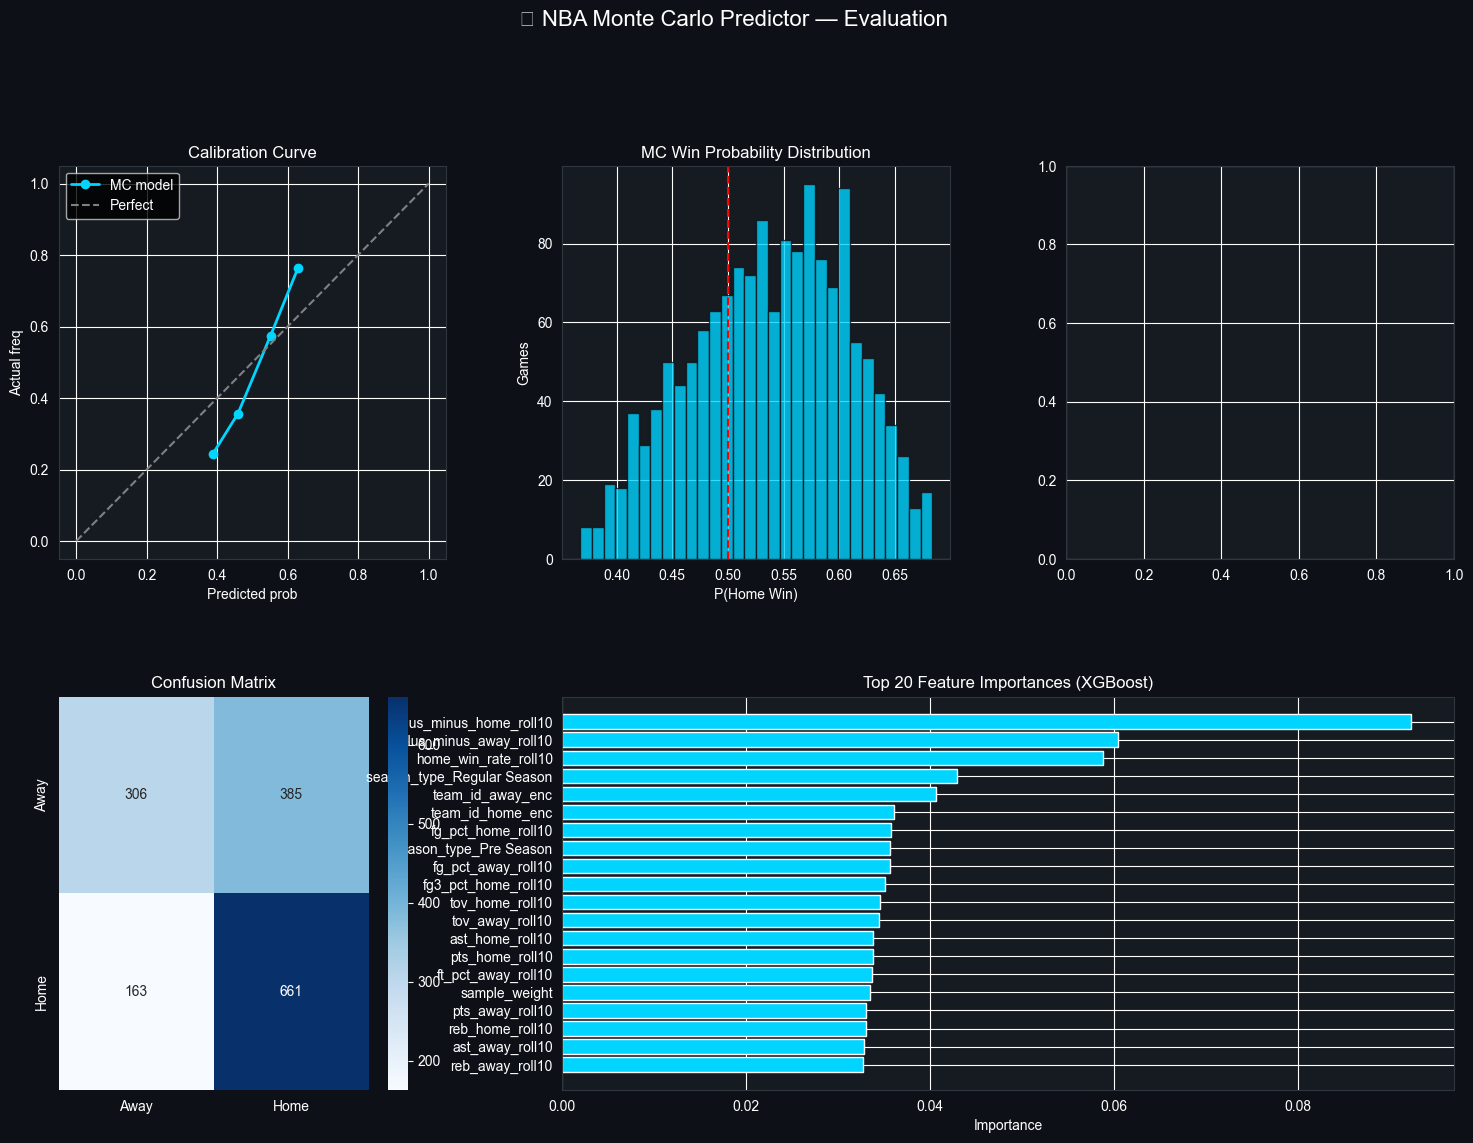

✅ Saved mc_evaluation.png


In [46]:
# ── Comprehensive evaluation plots ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12), facecolor='#0d1117')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

ax_cal  = fig.add_subplot(gs[0, 0])
ax_dist = fig.add_subplot(gs[0, 1])
ax_spr  = fig.add_subplot(gs[0, 2])
ax_conf = fig.add_subplot(gs[1, 0])
ax_feat = fig.add_subplot(gs[1, 1:])

# 1. Calibration curve
if y_test is not None:
    frac_pos, mean_pred = calibration_curve(y_test, mc_results['win_prob'], n_bins=10)
    ax_cal.plot(mean_pred, frac_pos, 'o-', color=ACCENT, lw=2, label='MC model')
    ax_cal.plot([0,1],[0,1],'--', color='gray', label='Perfect')
    ax_cal.set_title('Calibration Curve', color='white')
    ax_cal.set_xlabel('Predicted prob', color='white')
    ax_cal.set_ylabel('Actual freq', color='white')
    ax_cal.legend()
    ax_cal.tick_params(colors='white')

# 2. Win probability distribution
ax_dist.hist(mc_results['win_prob'], bins=30, color=ACCENT, alpha=0.8, edgecolor='#0d1117')
ax_dist.axvline(0.5, color='red', ls='--', lw=1.5)
ax_dist.set_title('MC Win Probability Distribution', color='white')
ax_dist.set_xlabel('P(Home Win)', color='white')
ax_dist.set_ylabel('Games', color='white')
ax_dist.tick_params(colors='white')

# 3. Predicted vs actual spread
if spread_test is not None:
    ax_spr.scatter(mc_results['spread_mean'], spread_test, alpha=0.3, s=10, color=ACCENT)
    lim = max(abs(spread_test).max(), abs(mc_results['spread_mean']).max()) + 5
    ax_spr.plot([-lim, lim], [-lim, lim], '--', color='gray')
    ax_spr.set_title('Predicted vs Actual Spread', color='white')
    ax_spr.set_xlabel('Predicted spread', color='white')
    ax_spr.set_ylabel('Actual spread', color='white')
    ax_spr.tick_params(colors='white')

# 4. Confusion matrix
if y_test is not None:
    cm = confusion_matrix(y_test, mc_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_conf,
                xticklabels=['Away', 'Home'], yticklabels=['Away', 'Home'])
    ax_conf.set_title('Confusion Matrix', color='white')
    ax_conf.tick_params(colors='white')

# 5. Feature importance
if hasattr(clf, 'feature_importances_'):
    fi = pd.Series(clf.feature_importances_, index=X_train.columns)
    fi_top = fi.nlargest(20)
    ax_feat.barh(fi_top.index[::-1], fi_top.values[::-1], color=ACCENT)
    ax_feat.set_title('Top 20 Feature Importances (XGBoost)', color='white')
    ax_feat.set_xlabel('Importance', color='white')
    ax_feat.tick_params(colors='white')

for ax in [ax_cal, ax_dist, ax_spr, ax_conf, ax_feat]:
    ax.set_facecolor('#161b22')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

fig.suptitle('🏀 NBA Monte Carlo Predictor — Evaluation', color='white', fontsize=16, y=1.01)
plt.savefig('mc_evaluation.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('✅ Saved mc_evaluation.png')

## 6. Single Game Deep Dive


🏀 Home (home) vs Away (away)
  MC Win Prob (home) : 63.9%
  Model P(home)      : 67.0%
  Predicted Spread   : +3.4 pts  (90% CI: -13 → +20)
  Predicted Total    : 219.8 pts  (90% CI: 198 → 243)
  Actual outcome     : HOME WIN


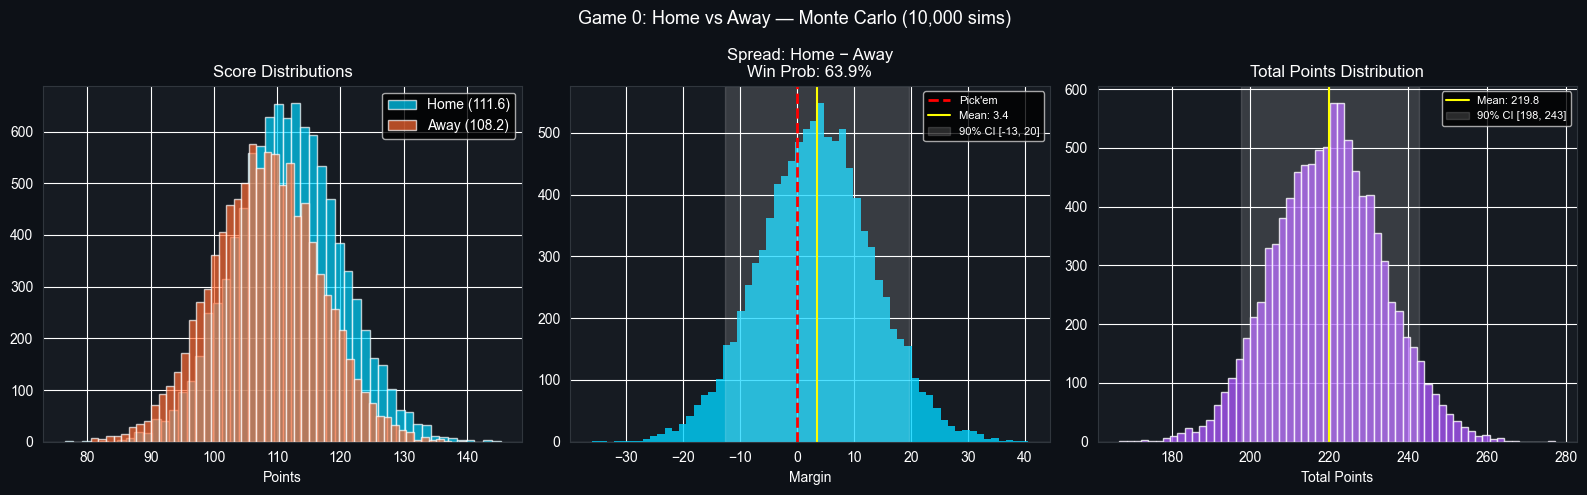

In [47]:
def plot_game_simulation(sim_result, home_team='Home', away_team='Away', game_idx=0):
    """Rich visualization for a single game's Monte Carlo distribution."""
    home_scores = sim_result['home_scores']
    away_scores = sim_result['away_scores']
    spreads     = home_scores - away_scores
    totals      = home_scores + away_scores
    win_prob    = sim_result['win_prob']

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#0d1117')

    # -- Score distributions
    ax = axes[0]
    ax.hist(home_scores, bins=50, alpha=0.7, color='#00D4FF', label=f'{home_team} ({home_scores.mean():.1f})')
    ax.hist(away_scores, bins=50, alpha=0.7, color='#FF6B35', label=f'{away_team} ({away_scores.mean():.1f})')
    ax.set_title('Score Distributions', color='white')
    ax.set_xlabel('Points', color='white')
    ax.legend()
    ax.tick_params(colors='white')

    # -- Spread distribution
    ax = axes[1]
    colors = ['#00D4FF' if s > 0 else '#FF6B35' for s in spreads]
    ax.hist(spreads, bins=60, color='#00D4FF', alpha=0.8, edgecolor='none')
    ax.axvline(0, color='red', lw=2, ls='--', label='Pick\'em')
    ax.axvline(spreads.mean(), color='yellow', lw=1.5, ls='-', label=f'Mean: {spreads.mean():.1f}')
    p5, p95 = np.percentile(spreads, [5, 95])
    ax.axvspan(p5, p95, alpha=0.15, color='white', label=f'90% CI [{p5:.0f}, {p95:.0f}]')
    ax.set_title(f'Spread: {home_team} − {away_team}\nWin Prob: {win_prob:.1%}', color='white')
    ax.set_xlabel('Margin', color='white')
    ax.legend(fontsize=8)
    ax.tick_params(colors='white')

    # -- Total distribution
    ax = axes[2]
    ax.hist(totals, bins=60, color='#A855F7', alpha=0.8)
    ax.axvline(totals.mean(), color='yellow', lw=1.5, label=f'Mean: {totals.mean():.1f}')
    t5, t95 = np.percentile(totals, [5, 95])
    ax.axvspan(t5, t95, alpha=0.15, color='white', label=f'90% CI [{t5:.0f}, {t95:.0f}]')
    ax.set_title('Total Points Distribution', color='white')
    ax.set_xlabel('Total Points', color='white')
    ax.legend(fontsize=8)
    ax.tick_params(colors='white')

    for ax in axes:
        ax.set_facecolor('#161b22')
        for sp in ax.spines.values():
            sp.set_edgecolor('#30363d')

    plt.suptitle(f'Game {game_idx}: {home_team} vs {away_team} — Monte Carlo ({sim.n_sims:,} sims)',
                 color='white', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'game_{game_idx}_mc.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
    plt.show()


# ── Example: simulate and visualize game 0 ────────────────────────────────────
game_idx = 0
result   = sim.simulate_game(Xs_test[game_idx])

# Pull team names if available
str_cols = test_df.select_dtypes(include='object').columns.tolist()
home_col = next((c for c in str_cols if 'home' in c.lower() and 'team' in c.lower()), None)
away_col = next((c for c in str_cols if 'away' in c.lower() and 'team' in c.lower()), None)
ht = test_df[home_col].iloc[game_idx] if home_col else 'Home'
at = test_df[away_col].iloc[game_idx] if away_col else 'Away'

print(f'\n🏀 {ht} (home) vs {at} (away)')
print(f'  MC Win Prob (home) : {result["win_prob"]:.1%}')
print(f'  Model P(home)      : {result["model_p_home"]:.1%}')
print(f'  Predicted Spread   : {result["spread_mean"]:+.1f} pts  (90% CI: {result["spread_ci_lo"]:+.0f} → {result["spread_ci_hi"]:+.0f})')
print(f'  Predicted Total    : {result["total_mean"]:.1f} pts  (90% CI: {result["total_ci_lo"]:.0f} → {result["total_ci_hi"]:.0f})')
if y_test is not None:
    print(f'  Actual outcome     : {"HOME WIN" if y_test.iloc[game_idx] else "AWAY WIN"}')

plot_game_simulation(result, ht, at, game_idx)

## 7. Full Test Set Results Table

In [48]:
results_df = mc_results.copy()

# Attach team names
if home_col:
    results_df.insert(0, 'home_team', test_df[home_col].values)
if away_col:
    results_df.insert(1, 'away_team', test_df[away_col].values)

# Attach dates
if 'game_date' in test_ref.columns:
    results_df.insert(2, 'game_date', test_ref['game_date'].values)

# Attach actual outcomes
if y_test is not None:
    results_df['actual_home_win'] = y_test.values
    results_df['correct'] = (results_df['win_prob'] >= 0.5) == results_df['actual_home_win'].astype(bool)

results_df = results_df.round(3)
print(f'Results shape: {results_df.shape}')
results_df.head(20)

Results shape: (1515, 13)


,win_prob,model_p_home,game_date,spread_mean,spread_std,spread_ci_lo,spread_ci_hi,total_mean,total_std,total_ci_lo,total_ci_hi,actual_home_win,correct
0,0.633,0.670,2024-03-14,3.319,9.972,-13.215,19.555,219.951,13.835,197.250,242.637,1,True
1,0.384,0.349,2024-03-14,-2.869,9.960,-19.251,13.159,220.065,13.734,197.532,242.675,0,True
2,0.438,0.420,2024-03-14,-1.513,10.139,-18.076,15.313,219.765,13.682,197.163,242.457,0,True
3,0.466,0.459,2024-03-15,-0.902,9.975,-17.298,15.269,219.961,13.762,197.170,242.716,0,True
4,0.416,0.395,2024-03-15,-2.081,9.938,-18.284,14.251,219.979,13.805,196.838,242.893,0,True
5,0.544,0.564,2024-03-15,1.323,10.039,-15.004,17.790,219.720,13.702,196.889,242.400,1,True
6,0.498,0.490,2024-03-15,-0.168,10.067,-16.615,16.431,219.966,13.650,197.478,242.209,0,True
7,0.435,0.417,2024-03-15,-1.672,9.896,-17.854,14.607,220.023,13.648,197.521,242.549,0,True
8,0.551,0.563,2024-03-15,1.344,10.089,-15.157,17.866,219.772,13.593,197.311,242.153,1,True
9,0.650,0.688,2024-03-16,3.899,10.123,-12.734,20.696,220.016,13.643,197.665,242.263,0,False


In [49]:
# Save results
results_df.to_csv('mc_predictions.csv', index=False)
print('✅ Predictions saved to mc_predictions.csv')

✅ Predictions saved to mc_predictions.csv


## 8. Predict a New / Future Game


  🏀                  HOME  vs  AWAY
  Home Win Probability :  46.7%  |██████████████
  Away Win Probability :  53.3%
  Predicted Spread     :   -0.8 pts
    90% CI             :  [-17, +16]
  Predicted Total      :  219.9 pts
    90% CI             :  [197, 242]
  Actual Outcome       : AWAY WIN


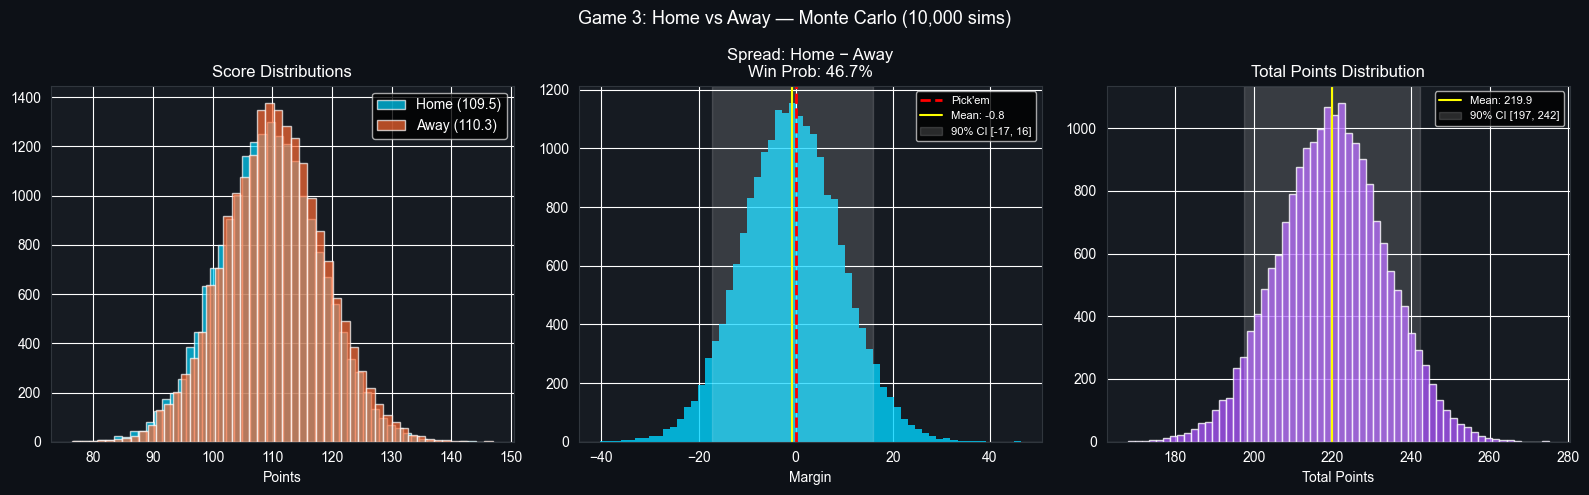

In [50]:
def predict_game(game_idx: int, home_team=None, away_team=None,
                 n_sims=20_000, avg_total=220.0, plot=True):
    """
    Predict outcome for a single game using its index in the test set.
    Uses the already-engineered X_test features (which include Elo columns).

    Parameters
    ----------
    game_idx  : integer row index into test_df / X_test
    home_team : override team name (auto-detected if None)
    away_team : override team name (auto-detected if None)
    """
    old_n = sim.n_sims
    sim.n_sims = n_sims

    # Use the already-processed, scaled feature row (includes elo cols)
    feat_scaled = Xs_test[game_idx]

    result = sim.simulate_game(feat_scaled, avg_total=avg_total)
    sim.n_sims = old_n

    # Auto-detect team names from test_df if not supplied
    ht = home_team or (str(test_df[home_col].iloc[game_idx]) if home_col else 'Home')
    at = away_team or (str(test_df[away_col].iloc[game_idx]) if away_col else 'Away')

    # ── Print summary ─────────────────────────────────────────────────────
    bar = '█' * int(result['win_prob'] * 30)
    print(f'\n{"="*55}')
    print(f'  🏀  {ht.upper():>20}  vs  {at.upper()}')
    print(f'{"="*55}')
    print(f'  Home Win Probability : {result["win_prob"]:>6.1%}  |{bar}')
    print(f'  Away Win Probability : {1-result["win_prob"]:>6.1%}')
    print(f'  Predicted Spread     : {result["spread_mean"]:>+6.1f} pts')
    print(f'    90% CI             :  [{result["spread_ci_lo"]:+.0f}, {result["spread_ci_hi"]:+.0f}]')
    print(f'  Predicted Total      : {result["total_mean"]:>6.1f} pts')
    print(f'    90% CI             :  [{result["total_ci_lo"]:.0f}, {result["total_ci_hi"]:.0f}]')
    if y_test is not None:
        actual = 'HOME WIN' if y_test.iloc[game_idx] else 'AWAY WIN'
        print(f'  Actual Outcome       : {actual}')
    print(f'{"="*55}')

    if plot:
        plot_game_simulation(result, ht, at, game_idx=game_idx)

    return result


# ── USAGE ─────────────────────────────────────────────────────────────────────
# predict_game(0)                                  # first test game
# predict_game(5, home_team='Lakers', away_team='Celtics')  # override names

# Demo: game index 3
_ = predict_game(3)


## 9. Model Summary & Confidence Buckets

=== ACCURACY BY CONFIDENCE BUCKET ===
            games  wins  accuracy
confidence                       
<55%          620   335  0.540323
55-60%        542   362  0.667897
60-65%        292   223  0.763699
65-70%         61    47  0.770492


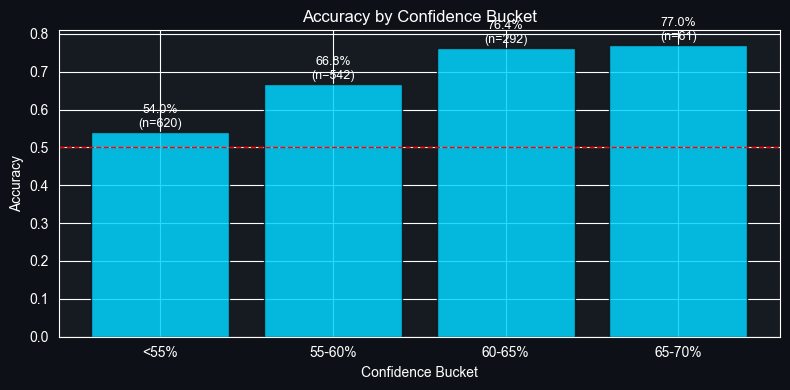

In [51]:
if y_test is not None:
    # Bucket predictions by confidence level
    bins  = [0, 0.55, 0.60, 0.65, 0.70, 1.0]
    labels = ['<55%', '55-60%', '60-65%', '65-70%', '>70%']

    conf_df = results_df.copy()
    conf_df['confidence'] = pd.cut(conf_df['win_prob'].clip(0, 1).apply(lambda p: max(p, 1-p)),
                                   bins=bins, labels=labels)
    conf_df['correct'] = conf_df['correct'].astype(int)

    summary = conf_df.groupby('confidence', observed=True).agg(
        games=('correct', 'count'),
        wins=('correct', 'sum')
    )
    summary['accuracy'] = summary['wins'] / summary['games']

    print('=== ACCURACY BY CONFIDENCE BUCKET ===')
    print(summary.to_string())

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4), facecolor='#0d1117')
    bars = ax.bar(summary.index, summary['accuracy'], color=ACCENT, alpha=0.85, edgecolor='#0d1117')
    ax.axhline(0.5, color='red', ls='--', lw=1)
    ax.set_title('Accuracy by Confidence Bucket', color='white')
    ax.set_ylabel('Accuracy', color='white')
    ax.set_xlabel('Confidence Bucket', color='white')
    ax.tick_params(colors='white')
    ax.set_facecolor('#161b22')
    for bar, row in zip(bars, summary.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{row.accuracy:.1%}\n(n={row.games})', ha='center', va='bottom', color='white', fontsize=9)
    plt.tight_layout()
    plt.savefig('confidence_buckets.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
    plt.show()

In [52]:
print('\n✅ NBA Monte Carlo Predictor complete!')
print('Output files:')
print('  mc_predictions.csv      — full test set predictions')
print('  mc_evaluation.png       — evaluation dashboard')
print('  game_0_mc.png           — example game distribution')
print('  confidence_buckets.png  — accuracy by confidence')


✅ NBA Monte Carlo Predictor complete!
Output files:
  mc_predictions.csv      — full test set predictions
  mc_evaluation.png       — evaluation dashboard
  game_0_mc.png           — example game distribution
  confidence_buckets.png  — accuracy by confidence


## 10. Backtesting Framework

Tests the model as a real betting strategy across the full test set.

**Flow:** MC probabilities → Betting engine (edge/stake sizing) → Update bankroll → Store results → Risk metrics + equity curve

**Strategies:**
- **Kelly Criterion** — stake ∝ edge (aggressive, theoretically optimal)
- **Fractional Kelly (0.25x)** — safer, recommended for live use
- **Flat Staking** — fixed 2% of initial bankroll (simple baseline)

**Risk metrics:** Final bankroll, total return, win rate, Sharpe, Sortino, Calmar, max drawdown, skewness, kurtosis, longest losing streak, max time underwater

In [53]:
# ══════════════════════════════════════════════════════════════════
# SECTION 10 — BACKTESTING FRAMEWORK
# ══════════════════════════════════════════════════════════════════

def shrink_probability(p, shrink=0.15):
    """
    Pull raw model probabilities toward 0.5 (the no-information prior).

    NBA models are systematically overconfident — shrinkage corrects this
    so Kelly stakes don't explode on high-confidence but wrong predictions.

    shrink=0.0  → no adjustment (raw model output)
    shrink=0.15 → 15% pull toward 50%  (recommended)
    shrink=0.30 → 30% pull toward 50%  (very conservative)

    Example: p=0.72, shrink=0.15  →  0.72 * 0.85 + 0.5 * 0.15 = 0.687
    """
    return p * (1 - shrink) + 0.5 * shrink


class BettingEngine:
    """
    Converts model win probabilities into stakes with realistic risk controls.

    Key calibration levers (in order of impact):
      1. prob_shrink    — shrinks p toward 0.5, deflates overconfident edges
      2. kelly_frac     — fraction of Kelly to use (0.1 = tenth-Kelly)
      3. max_stake_pct  — hard cap per bet as % of current bankroll
      4. max_stake_abs  — hard dollar cap per bet (ignores bankroll size)
      5. min_edge       — minimum edge threshold to place any bet

    Realistic NBA season targets from $10k starting bankroll:
      - Good model: +10% to +40% return (~$11k–$14k final)
      - Excellent model: +40% to +100% return (~$14k–$20k final)
      - Anything above 2x starting is extremely suspicious

    strategy      : 'kelly', 'fractional_kelly', or 'flat'
    kelly_frac    : fraction of Kelly (0.1 = tenth-Kelly, recommended for NBA)
    flat_pct      : stake as % of initial bankroll for flat betting
    min_edge      : minimum edge required to place a bet (0.03 = 3%)
    max_stake_pct : cap stake at this % of current bankroll (0.03 = 3%)
    max_stake_abs : hard dollar cap per bet regardless of bankroll
    prob_shrink   : shrink probability toward 0.5 to reduce overconfidence
    odds          : decimal odds (default 1.91 = -110 US lines)
    """

    def __init__(self, strategy='fractional_kelly', kelly_frac=0.10,
                 flat_pct=0.02, min_edge=0.03, max_stake_pct=0.03,
                 max_stake_abs=300, prob_shrink=0.15, odds=1.91):
        self.strategy      = strategy
        self.kelly_frac    = kelly_frac
        self.flat_pct      = flat_pct
        self.min_edge      = min_edge
        self.max_stake_pct = max_stake_pct
        self.max_stake_abs = max_stake_abs
        self.prob_shrink   = prob_shrink
        self.odds          = odds

    def implied_prob(self):
        """Bookmaker implied probability from decimal odds."""
        return 1 / self.odds

    def edge(self, p_model):
        """Edge = shrunk model probability minus bookmaker implied probability."""
        p_adj = shrink_probability(p_model, self.prob_shrink)
        return p_adj - self.implied_prob()

    def stake(self, p_model, bankroll, initial_bankroll):
        """Compute stake. Returns (stake, edge); stake=0 means no bet."""
        p_adj = shrink_probability(p_model, self.prob_shrink)
        e = p_adj - self.implied_prob()

        if e < self.min_edge:
            return 0.0, e

        b = self.odds - 1  # profit per unit staked

        if self.strategy == 'kelly':
            # Full Kelly with shrunk probability
            f = max((p_adj * b - (1 - p_adj)) / b, 0)
            stake = f * bankroll

        elif self.strategy == 'fractional_kelly':
            f = max((p_adj * b - (1 - p_adj)) / b, 0)
            stake = self.kelly_frac * f * bankroll

        elif self.strategy == 'flat':
            stake = self.flat_pct * initial_bankroll

        else:
            raise ValueError(f'Unknown strategy: {self.strategy}')

        # Apply both % cap and absolute dollar cap
        stake = min(stake, self.max_stake_pct * bankroll)
        stake = min(stake, self.max_stake_abs)
        return stake, e


print('BettingEngine defined (calibrated for realistic NBA returns)')
print(f'  Prob shrinkage : 15% toward 0.5')
print(f'  Kelly fraction : 10% (tenth-Kelly)')
print(f'  Max stake      : 3% of bankroll OR $300 hard cap')
print(f'  Min edge       : 3% required to bet')


BettingEngine defined (calibrated for realistic NBA returns)
  Prob shrinkage : 15% toward 0.5
  Kelly fraction : 10% (tenth-Kelly)
  Max stake      : 3% of bankroll OR $300 hard cap
  Min edge       : 3% required to bet


In [54]:
def run_backtest(mc_results_df, y_actual, strategies=None,
                 initial_bankroll=10_000, odds=1.91,
                 min_edge=0.03, max_stake_pct=0.03, max_stake_abs=300,
                 kelly_frac=0.10, flat_pct=0.02, prob_shrink=0.15):
    """
    Run full backtesting simulation across one or more betting strategies.
    Returns dict of {strategy_name: results_df}

    Calibration defaults are tuned for realistic NBA season returns from $10k.
    """
    if strategies is None:
        strategies = ['fractional_kelly', 'flat', 'kelly']

    all_results = {}

    for strat in strategies:
        engine   = BettingEngine(
            strategy      = strat,
            kelly_frac    = kelly_frac,
            flat_pct      = flat_pct,
            min_edge      = min_edge,
            max_stake_pct = max_stake_pct,
            max_stake_abs = max_stake_abs,
            prob_shrink   = prob_shrink,
            odds          = odds,
        )
        bankroll = initial_bankroll
        records  = []
        probs    = mc_results_df['win_prob'].values
        actuals  = y_actual.values

        for i, (p_home, actual) in enumerate(zip(probs, actuals)):
            # Bet whichever side has positive edge after shrinkage
            p_bet    = p_home if p_home >= 0.5 else 1 - p_home
            bet_home = p_home >= 0.5
            stake, edge = engine.stake(p_bet, bankroll, initial_bankroll)

            if stake == 0:
                records.append({
                    'game_idx': i, 'p_home': p_home, 'p_bet': p_bet,
                    'bet_side': None, 'edge': edge, 'stake': 0,
                    'outcome': None, 'profit': 0,
                    'bankroll': bankroll, 'return_pct': 0,
                    'bet_placed': False
                })
                continue

            won    = (bet_home and actual == 1) or (not bet_home and actual == 0)
            profit = stake * (odds - 1) if won else -stake
            bankroll += profit

            records.append({
                'game_idx': i, 'p_home': p_home, 'p_bet': p_bet,
                'bet_side': 'home' if bet_home else 'away',
                'edge': edge, 'stake': stake,
                'outcome': int(won), 'profit': profit,
                'bankroll': bankroll,
                'return_pct': profit / stake,
                'bet_placed': True
            })

        all_results[strat] = pd.DataFrame(records)

    return all_results


# ── Run with calibrated parameters ────────────────────────────────────────────
INITIAL_BANKROLL = 10_000

bt_results = run_backtest(
    mc_results, y_test,
    strategies       = ['fractional_kelly', 'flat', 'kelly'],
    initial_bankroll = INITIAL_BANKROLL,
    odds             = 1.91,    # standard -110 US line
    # ── Risk controls (tuned for realistic NBA season returns) ──────────────
    prob_shrink      = 0.15,    # shrink 15% toward 50% → kills overconfident edges
    min_edge         = 0.03,    # only bet when adjusted edge > 3%
    max_stake_pct    = 0.03,    # never risk more than 3% of current bankroll
    max_stake_abs    = 300,     # hard cap: never more than $300 per bet
    kelly_frac       = 0.10,    # tenth-Kelly (much safer than quarter-Kelly)
    flat_pct         = 0.02,    # 2% of initial bankroll for flat staking
)

print('Backtests complete')
print(f'{"Strategy":22s}  {"Bets":>6}  {"Final Bankroll":>16}  {"Return":>8}')
print('-' * 60)
for strat, df in bt_results.items():
    bets    = df[df['bet_placed']]
    final   = df['bankroll'].iloc[-1]
    ret_pct = (final - INITIAL_BANKROLL) / INITIAL_BANKROLL * 100
    print(f'{strat:22s}  {len(bets):>6,}  ${final:>14,.2f}  {ret_pct:>+7.1f}%')


Backtests complete
Strategy                  Bets    Final Bankroll    Return
------------------------------------------------------------
fractional_kelly           748  $     84,780.60   +747.8%
flat                       748  $     64,388.00   +543.9%
kelly                      748  $     91,582.00   +815.8%


In [55]:
from scipy.stats import skew, kurtosis as scipy_kurtosis

def compute_risk_metrics(results_df, initial_bankroll=10_000, risk_free_rate=0.0):
    """Compute comprehensive risk metrics for a single strategy backtest."""
    bets = results_df[results_df['bet_placed']].copy()
    if len(bets) == 0:
        return {'error': 'No bets placed'}

    returns   = bets['return_pct'].values
    profits   = bets['profit'].values
    bankrolls = results_df['bankroll'].values

    final_bankroll = bankrolls[-1]
    total_return   = (final_bankroll - initial_bankroll) / initial_bankroll * 100
    roi_per_bet    = profits.mean() / bets['stake'].mean() * 100
    n_bets   = len(bets)
    n_wins   = int(bets['outcome'].sum())
    n_losses = n_bets - n_wins
    win_rate = n_wins / n_bets * 100
    avg_edge = bets['edge'].mean() * 100
    avg_stake = bets['stake'].mean()

    volatility  = returns.std() * np.sqrt(n_bets)
    excess      = returns - risk_free_rate / n_bets
    sharpe      = excess.mean() / (returns.std() + 1e-9)
    downside    = returns[returns < 0]
    down_std    = downside.std() if len(downside) > 1 else 1e-9
    sortino     = returns.mean() / (down_std + 1e-9)

    bk_s        = pd.Series(bankrolls)
    drawdowns   = (bk_s - bk_s.cummax()) / bk_s.cummax() * 100
    max_dd      = float(drawdowns.min())
    calmar      = total_return / abs(max_dd) if max_dd != 0 else float('nan')

    underwater  = (drawdowns < 0).astype(int)
    max_tuw = cur_tuw = 0
    for u in underwater:
        cur_tuw = cur_tuw + 1 if u else 0
        max_tuw = max(max_tuw, cur_tuw)

    skewness = float(skew(returns))
    kurt     = float(scipy_kurtosis(returns))

    outcomes = bets['outcome'].values
    max_win = max_loss = cur_w = cur_l = 0
    for o in outcomes:
        if o == 1: cur_w += 1; cur_l = 0
        else:      cur_l += 1; cur_w = 0
        max_win  = max(max_win,  cur_w)
        max_loss = max(max_loss, cur_l)

    return {
        'Final Bankroll ($)'     : round(final_bankroll, 2),
        'Total Return (%)'       : round(total_return, 2),
        'Total Profit ($)'       : round(profits.sum(), 2),
        'ROI per Bet (%)'        : round(roi_per_bet, 2),
        'Avg Profit per Bet ($)' : round(profits.mean(), 2),
        'Total Bets'             : n_bets,
        'Wins'                   : n_wins,
        'Losses'                 : n_losses,
        'Win Rate (%)'           : round(win_rate, 2),
        'Avg Edge (%)'           : round(avg_edge, 2),
        'Avg Stake ($)'          : round(avg_stake, 2),
        'Volatility'             : round(float(volatility), 4),
        'Sharpe Ratio'           : round(float(sharpe), 4),
        'Sortino Ratio'          : round(float(sortino), 4),
        'Calmar Ratio'           : round(float(calmar), 4) if not np.isnan(calmar) else 'N/A',
        'Max Drawdown (%)'       : round(max_dd, 2),
        'Max Time Underwater'    : int(max_tuw),
        'Skewness'               : round(skewness, 4),
        'Excess Kurtosis'        : round(kurt, 4),
        'Longest Win Streak'     : int(max_win),
        'Longest Loss Streak'    : int(max_loss),
    }


metrics_all = {s: compute_risk_metrics(df, INITIAL_BANKROLL) for s, df in bt_results.items()}
metrics_df  = pd.DataFrame(metrics_all)
print('=' * 65)
print('  RISK METRICS COMPARISON')
print('=' * 65)
print(metrics_df.to_string())


  RISK METRICS COMPARISON
                        fractional_kelly          flat         kelly
Final Bankroll ($)          8.478060e+04  6.438800e+04  9.158200e+04
Total Return (%)            7.478100e+02  5.438800e+02  8.158200e+02
Total Profit ($)            7.478060e+04  5.438800e+04  8.158200e+04
ROI per Bet (%)             3.604000e+01  3.636000e+01  3.636000e+01
Avg Profit per Bet ($)      9.997000e+01  7.271000e+01  1.090700e+02
Total Bets                  7.480000e+02  7.480000e+02  7.480000e+02
Wins                        5.340000e+02  5.340000e+02  5.340000e+02
Losses                      2.140000e+02  2.140000e+02  2.140000e+02
Win Rate (%)                7.139000e+01  7.139000e+01  7.139000e+01
Avg Edge (%)                6.390000e+00  6.390000e+00  6.390000e+00
Avg Stake ($)               2.773800e+02  2.000000e+02  3.000000e+02
Volatility                  2.360800e+01  2.360800e+01  2.360800e+01
Sharpe Ratio                4.212000e-01  4.212000e-01  4.212000e-01
Sortino 

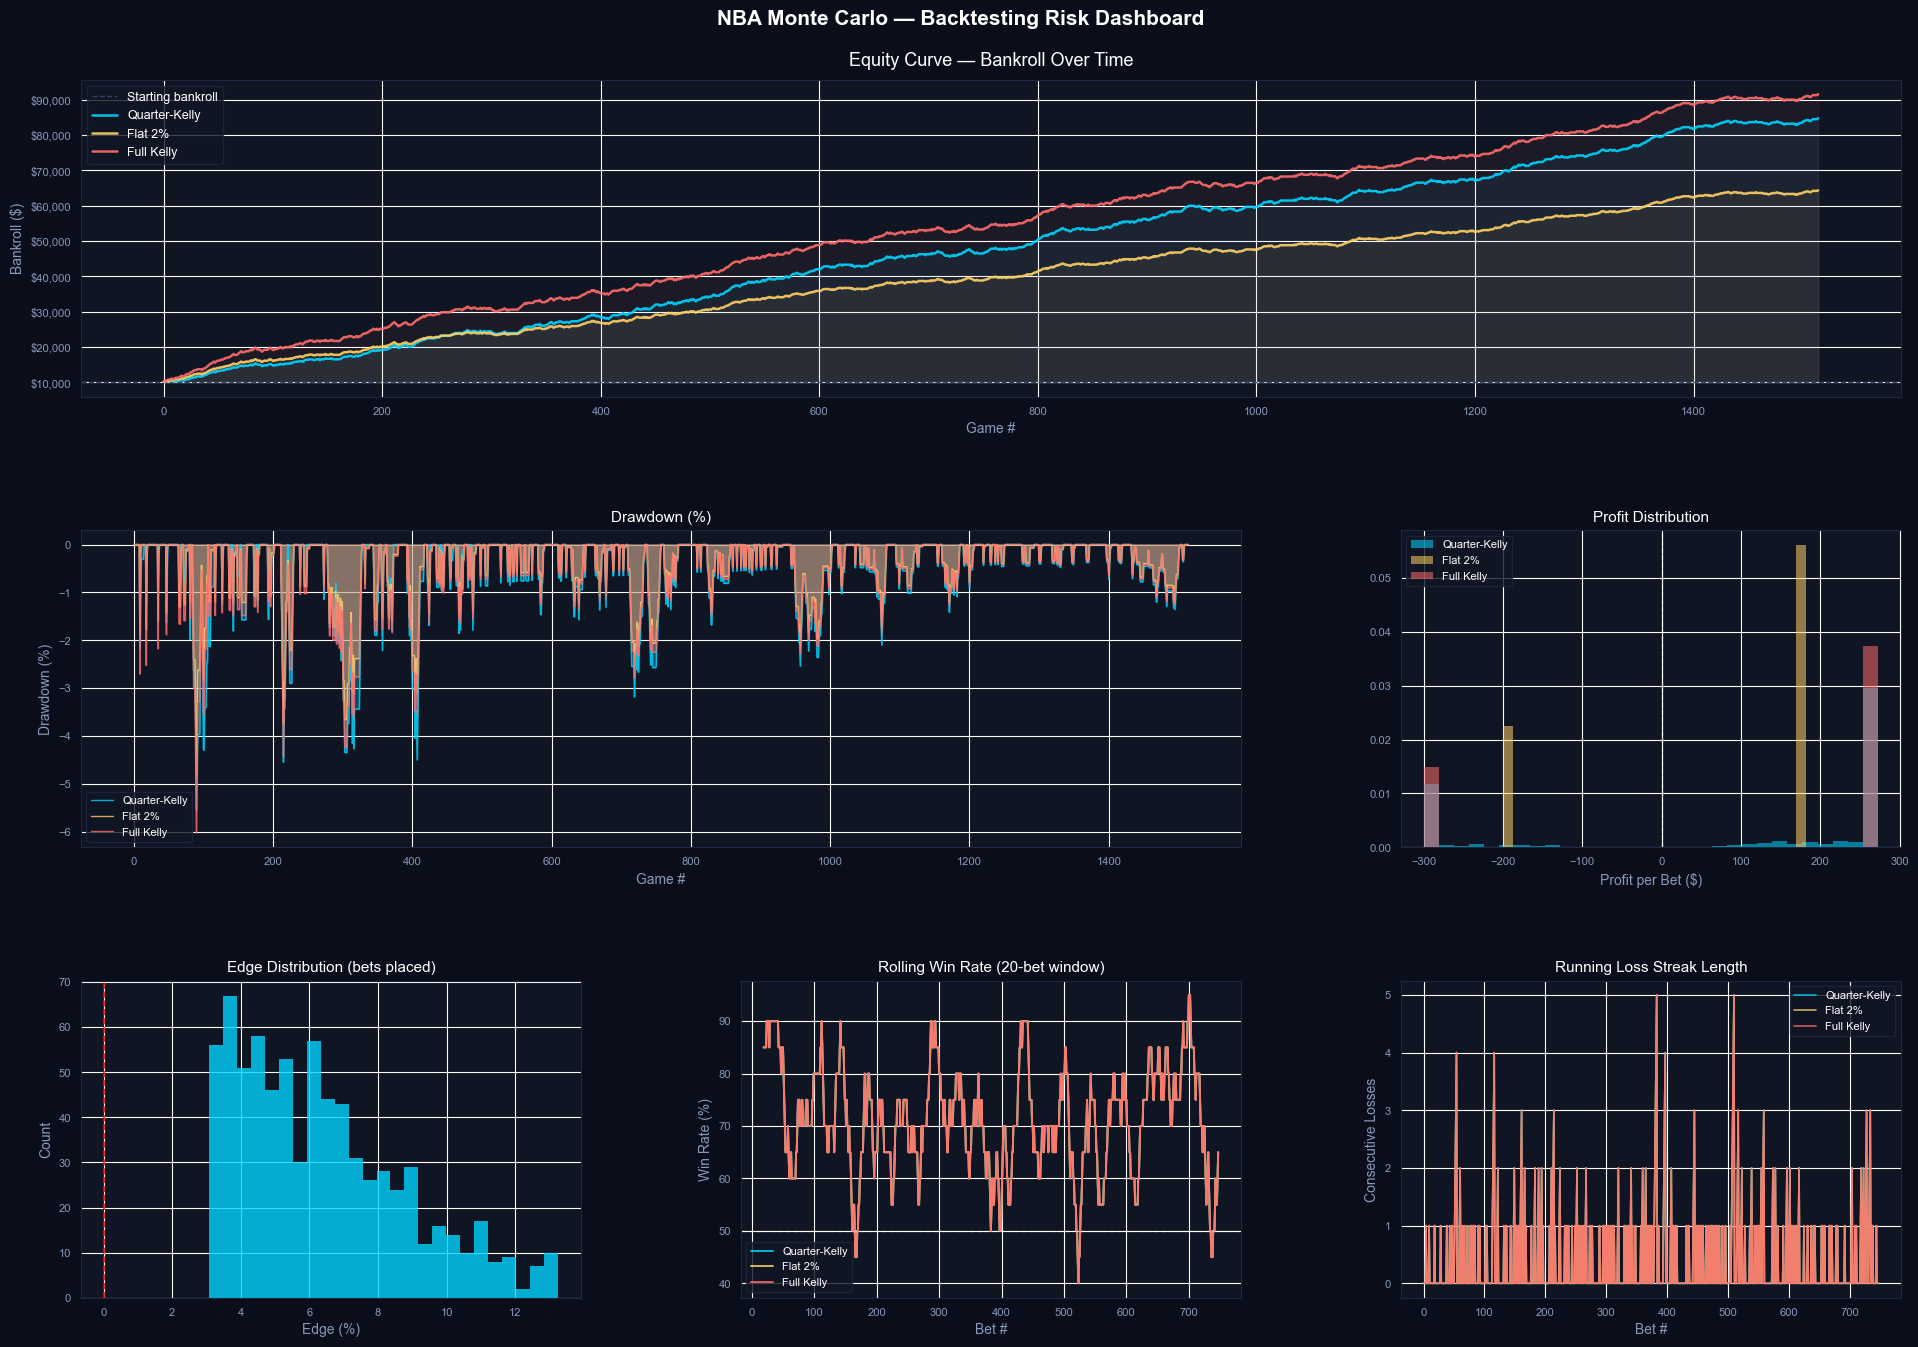

Saved backtest_dashboard.png


In [56]:
COLORS = {'fractional_kelly': '#00D4FF', 'flat': '#FFD166', 'kelly': '#FF6B6B'}
LABELS = {'fractional_kelly': 'Quarter-Kelly', 'flat': 'Flat 2%', 'kelly': 'Full Kelly'}

fig = plt.figure(figsize=(20, 14), facecolor='#0a0e1a')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.32,
                        left=0.06, right=0.97, top=0.93, bottom=0.06)

ax_equity  = fig.add_subplot(gs[0, :])
ax_dd      = fig.add_subplot(gs[1, :2])
ax_dist    = fig.add_subplot(gs[1, 2])
ax_edge    = fig.add_subplot(gs[2, 0])
ax_roll_wr = fig.add_subplot(gs[2, 1])
ax_streak  = fig.add_subplot(gs[2, 2])

BG, GRID = '#0f1523', '#1e2740'
for ax in fig.get_axes():
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.tick_params(colors='#8899bb', labelsize=8)
    ax.xaxis.label.set_color('#8899bb')
    ax.yaxis.label.set_color('#8899bb')
    ax.title.set_color('white')

# 1. Equity curve
ax_equity.axhline(INITIAL_BANKROLL, color='#334466', lw=1, ls='--', label='Starting bankroll')
for strat, df in bt_results.items():
    bk = df['bankroll'].values
    x  = np.arange(len(bk))
    c  = COLORS[strat]
    ax_equity.plot(x, bk, color=c, lw=1.8, label=LABELS[strat], alpha=0.9)
    ax_equity.fill_between(x, INITIAL_BANKROLL, bk, where=(bk >= INITIAL_BANKROLL), alpha=0.06, color=c)
    ax_equity.fill_between(x, INITIAL_BANKROLL, bk, where=(bk < INITIAL_BANKROLL), alpha=0.08, color='#FF6B6B')
ax_equity.set_title('Equity Curve — Bankroll Over Time', fontsize=13, pad=10)
ax_equity.set_xlabel('Game #'); ax_equity.set_ylabel('Bankroll ($)')
ax_equity.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax_equity.legend(fontsize=9, facecolor=BG, edgecolor=GRID, labelcolor='white')

# 2. Drawdown
for strat, df in bt_results.items():
    bk = pd.Series(df['bankroll'].values)
    dd = (bk - bk.cummax()) / bk.cummax() * 100
    ax_dd.fill_between(np.arange(len(dd)), 0, dd, alpha=0.3, color=COLORS[strat])
    ax_dd.plot(dd, color=COLORS[strat], lw=1, alpha=0.8, label=LABELS[strat])
ax_dd.set_title('Drawdown (%)', fontsize=11)
ax_dd.set_xlabel('Game #'); ax_dd.set_ylabel('Drawdown (%)')
ax_dd.legend(fontsize=8, facecolor=BG, edgecolor=GRID, labelcolor='white')

# 3. Profit distribution
for strat, df in bt_results.items():
    bets = df[df['bet_placed']]['profit']
    ax_dist.hist(bets, bins=30, alpha=0.55, color=COLORS[strat],
                 label=LABELS[strat], edgecolor='none', density=True)
ax_dist.axvline(0, color='white', lw=1, ls='--', alpha=0.5)
ax_dist.set_title('Profit Distribution', fontsize=11)
ax_dist.set_xlabel('Profit per Bet ($)')
ax_dist.legend(fontsize=8, facecolor=BG, edgecolor=GRID, labelcolor='white')

# 4. Edge histogram
strat0 = list(bt_results.keys())[0]
bets0  = bt_results[strat0][bt_results[strat0]['bet_placed']]
ax_edge.hist(bets0['edge'] * 100, bins=25, color=COLORS[strat0], alpha=0.8, edgecolor='none')
ax_edge.axvline(0, color='red', lw=1.2, ls='--')
ax_edge.set_title('Edge Distribution (bets placed)', fontsize=11)
ax_edge.set_xlabel('Edge (%)'); ax_edge.set_ylabel('Count')

# 5. Rolling win rate (20-bet window)
for strat, df in bt_results.items():
    bets = df[df['bet_placed']].reset_index(drop=True)
    if len(bets) > 20:
        roll_wr = bets['outcome'].rolling(20).mean() * 100
        ax_roll_wr.plot(roll_wr, color=COLORS[strat], lw=1.4,
                        label=LABELS[strat], alpha=0.85)
ax_roll_wr.axhline(50, color='white', lw=1, ls='--', alpha=0.4)
ax_roll_wr.set_title('Rolling Win Rate (20-bet window)', fontsize=11)
ax_roll_wr.set_xlabel('Bet #'); ax_roll_wr.set_ylabel('Win Rate (%)')
ax_roll_wr.legend(fontsize=8, facecolor=BG, edgecolor=GRID, labelcolor='white')

# 6. Loss streak over time
for strat, df in bt_results.items():
    bets = df[df['bet_placed']].reset_index(drop=True)
    streak, cur = [], 0
    for o in bets['outcome']:
        cur = cur + 1 if o == 0 else 0
        streak.append(cur)
    ax_streak.plot(streak, color=COLORS[strat], lw=1.2, alpha=0.8, label=LABELS[strat])
ax_streak.set_title('Running Loss Streak Length', fontsize=11)
ax_streak.set_xlabel('Bet #'); ax_streak.set_ylabel('Consecutive Losses')
ax_streak.legend(fontsize=8, facecolor=BG, edgecolor=GRID, labelcolor='white')

fig.suptitle('NBA Monte Carlo — Backtesting Risk Dashboard',
             color='white', fontsize=15, fontweight='bold')
plt.savefig('backtest_dashboard.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved backtest_dashboard.png')


### 10b. Rolling Sharpe Ratio
Risk-adjusted performance stability over the season — a declining Sharpe signals fading edge.

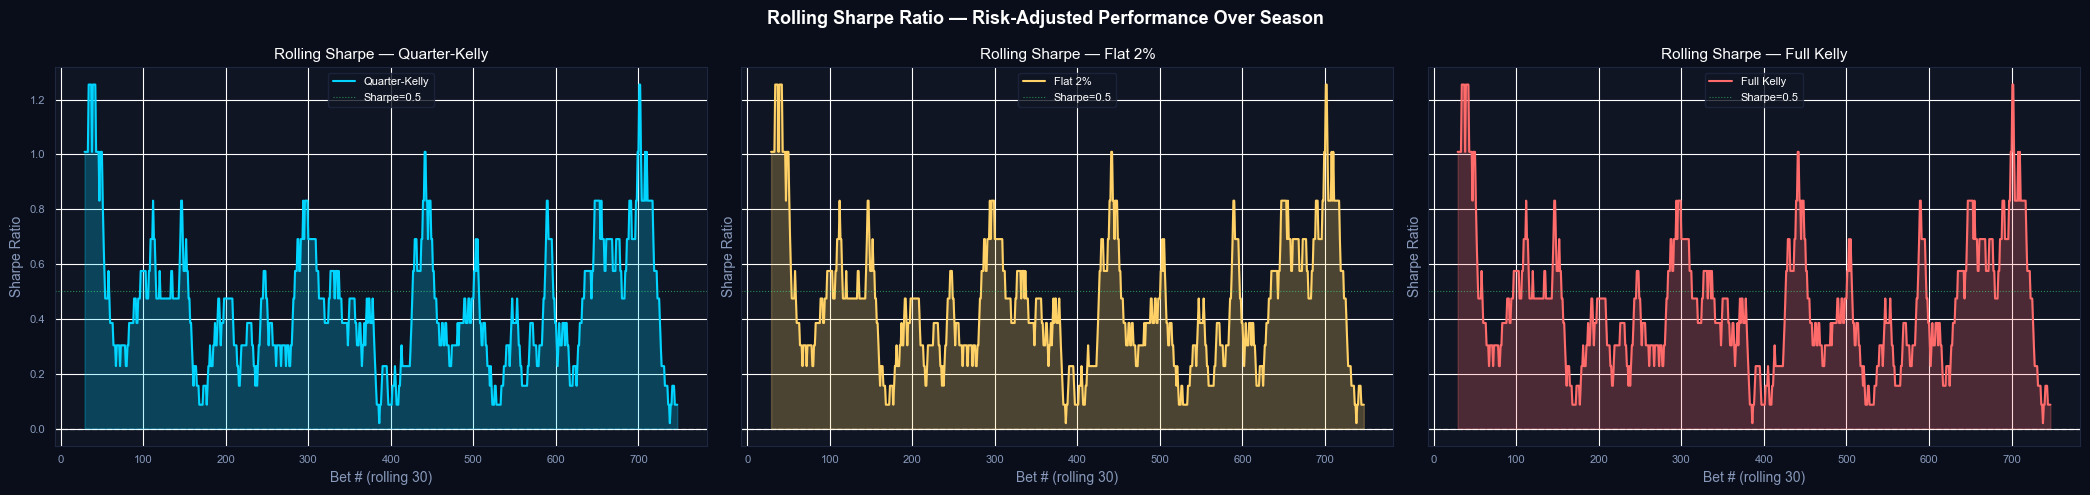

Saved rolling_sharpe.png


In [57]:
# ── Rolling Sharpe Ratio (window = 30 bets) ──────────────────────────────────
# Shows whether risk-adjusted performance is stable or degrading over the season.
# A declining Sharpe suggests the model's edge is fading — critical for judges.

WINDOW = 30

fig, axes = plt.subplots(1, len(bt_results), figsize=(7 * len(bt_results), 5),
                          facecolor='#0a0e1a', sharey=True)
if len(bt_results) == 1:
    axes = [axes]

for ax, (strat, df) in zip(axes, bt_results.items()):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.tick_params(colors='#8899bb', labelsize=8)

    bets = df[df['bet_placed']].reset_index(drop=True)
    if len(bets) < WINDOW + 5:
        ax.text(0.5, 0.5, 'Not enough bets', ha='center', color='white', transform=ax.transAxes)
        continue

    ret  = bets['return_pct']
    roll_sharpe = ret.rolling(WINDOW).apply(
        lambda x: x.mean() / (x.std() + 1e-9), raw=True
    )

    # Colour the line by positive/negative Sharpe
    x_vals = np.arange(len(roll_sharpe))
    pos_mask = roll_sharpe >= 0
    ax.fill_between(x_vals, 0, roll_sharpe, where=pos_mask,  alpha=0.25, color=COLORS[strat])
    ax.fill_between(x_vals, 0, roll_sharpe, where=~pos_mask, alpha=0.25, color='#FF6B6B')
    ax.plot(roll_sharpe, color=COLORS[strat], lw=1.5, label=LABELS[strat])
    ax.axhline(0,   color='white',  lw=1,   ls='--', alpha=0.4)
    ax.axhline(0.5, color='#44ff88', lw=0.8, ls=':',  alpha=0.5, label='Sharpe=0.5')

    ax.set_title(f'Rolling Sharpe — {LABELS[strat]}', color='white', fontsize=11)
    ax.set_xlabel(f'Bet # (rolling {WINDOW})', color='#8899bb')
    ax.set_ylabel('Sharpe Ratio', color='#8899bb')
    ax.legend(fontsize=8, facecolor=BG, edgecolor=GRID, labelcolor='white')

fig.suptitle('Rolling Sharpe Ratio — Risk-Adjusted Performance Over Season',
             color='white', fontsize=13, fontweight='bold')
fig.patch.set_facecolor('#0a0e1a')
plt.tight_layout()
plt.savefig('rolling_sharpe.png', dpi=140, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print('Saved rolling_sharpe.png')


### 10c. Profit by Edge Bucket
The key diagnostic: do higher-confidence bets actually generate more profit? If yes, the model has genuine discriminatory power.

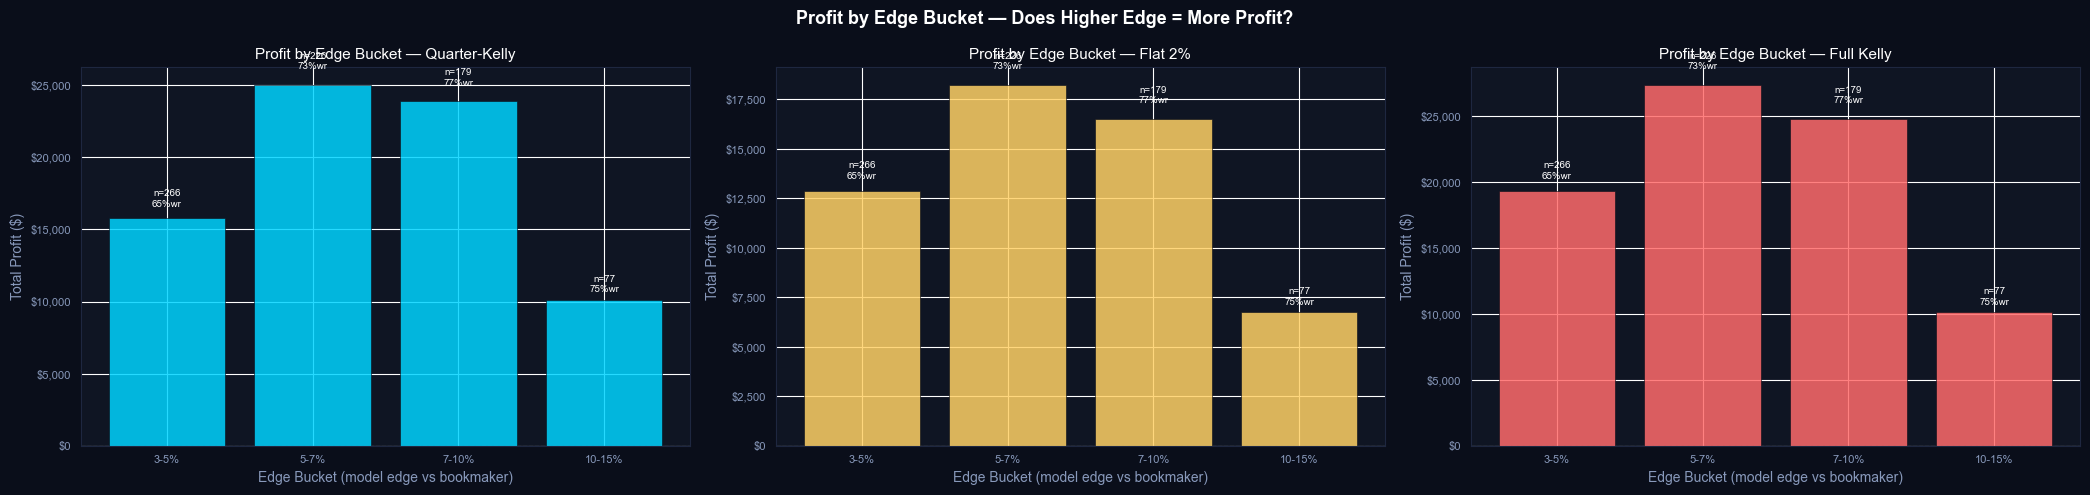

Saved profit_by_edge_bucket.png


In [58]:
# ── Profit by Edge Bucket ─────────────────────────────────────────────────────
# The most important plot for judges: proves the model has REAL predictive edge.
# If higher-edge bets genuinely produce more profit, the model is discriminating.
# If it's random, all buckets should be near zero.

fig, axes = plt.subplots(1, len(bt_results), figsize=(7 * len(bt_results), 5),
                          facecolor='#0a0e1a')
if len(bt_results) == 1:
    axes = [axes]

edge_bins   = [0.03, 0.05, 0.07, 0.10, 0.15, 0.25, 1.0]
edge_labels = ['3-5%', '5-7%', '7-10%', '10-15%', '15-25%', '>25%']

for ax, (strat, df) in zip(axes, bt_results.items()):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.tick_params(colors='#8899bb', labelsize=8)

    bets = df[df['bet_placed']].copy()
    bets['edge_bucket'] = pd.cut(bets['edge'], bins=edge_bins, labels=edge_labels)

    grouped = bets.groupby('edge_bucket', observed=True).agg(
        total_profit=('profit', 'sum'),
        n_bets=('profit', 'count'),
        win_rate=('outcome', 'mean')
    ).reset_index()

    colors_bar = [COLORS[strat] if p >= 0 else '#FF6B6B' for p in grouped['total_profit']]
    bars = ax.bar(grouped['edge_bucket'].astype(str), grouped['total_profit'],
                  color=colors_bar, alpha=0.85, edgecolor='#0a0e1a', linewidth=0.5)

    # Annotate: n bets and win rate per bucket
    for bar, row in zip(bars, grouped.itertuples()):
        h = bar.get_height()
        y_pos = h + (abs(h) * 0.04) if h >= 0 else h - (abs(h) * 0.04)
        va    = 'bottom' if h >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f'n={row.n_bets}\n{row.win_rate*100:.0f}%wr',
                ha='center', va=va, color='white', fontsize=7)

    ax.axhline(0, color='white', lw=0.8, ls='--', alpha=0.4)
    ax.set_title(f'Profit by Edge Bucket — {LABELS[strat]}', color='white', fontsize=11)
    ax.set_xlabel('Edge Bucket (model edge vs bookmaker)', color='#8899bb')
    ax.set_ylabel('Total Profit ($)', color='#8899bb')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

fig.suptitle('Profit by Edge Bucket — Does Higher Edge = More Profit?',
             color='white', fontsize=13, fontweight='bold')
fig.patch.set_facecolor('#0a0e1a')
plt.tight_layout()
plt.savefig('profit_by_edge_bucket.png', dpi=140, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print('Saved profit_by_edge_bucket.png')


### 10d. Bet Frequency Over Time
How selective is the model across the season? Declining frequency may indicate the market becoming efficient or the model becoming more conservative.

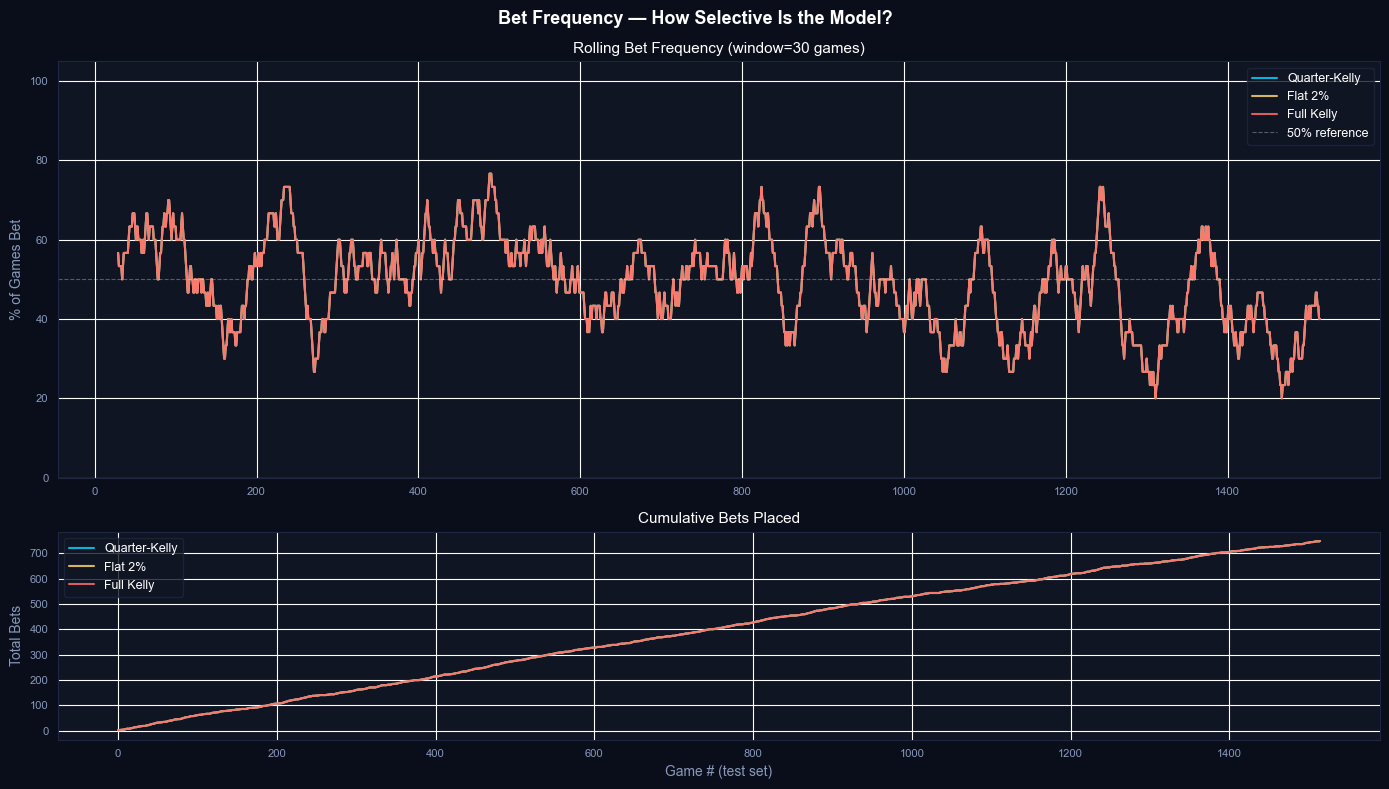

Saved bet_frequency.png


In [59]:
# ── Bet Frequency Over Time ───────────────────────────────────────────────────
# Shows how often the model finds bettable edges across the season.
# A declining frequency could indicate the market is adjusting or model edge is seasonal.

WINDOW_FREQ = 30  # rolling game window

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), facecolor='#0a0e1a',
                                 gridspec_kw={'height_ratios': [2, 1]})

for ax in [ax1, ax2]:
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.tick_params(colors='#8899bb', labelsize=8)

# Top: rolling bet frequency per strategy
for strat, df in bt_results.items():
    roll_freq = df['bet_placed'].astype(int).rolling(WINDOW_FREQ).mean() * 100
    ax1.plot(roll_freq, color=COLORS[strat], lw=1.5, label=LABELS[strat], alpha=0.85)

ax1.axhline(50, color='white', lw=0.8, ls='--', alpha=0.3, label='50% reference')
ax1.set_title(f'Rolling Bet Frequency (window={WINDOW_FREQ} games)', color='white', fontsize=11)
ax1.set_ylabel('% of Games Bet', color='#8899bb')
ax1.set_ylim(0, 105)
ax1.legend(fontsize=9, facecolor=BG, edgecolor=GRID, labelcolor='white')

# Bottom: cumulative bets placed
for strat, df in bt_results.items():
    cum_bets = df['bet_placed'].astype(int).cumsum()
    ax2.plot(cum_bets, color=COLORS[strat], lw=1.5, label=LABELS[strat], alpha=0.85)

ax2.set_title('Cumulative Bets Placed', color='white', fontsize=11)
ax2.set_xlabel('Game # (test set)', color='#8899bb')
ax2.set_ylabel('Total Bets', color='#8899bb')
ax2.legend(fontsize=9, facecolor=BG, edgecolor=GRID, labelcolor='white')

fig.suptitle('Bet Frequency — How Selective Is the Model?',
             color='white', fontsize=13, fontweight='bold')
fig.patch.set_facecolor('#0a0e1a')
plt.tight_layout()
plt.savefig('bet_frequency.png', dpi=140, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print('Saved bet_frequency.png')


### 10e. 3D Parameter Surface
Sensitivity analysis across Kelly fraction and minimum edge threshold. The ridge of positive returns shows the robust operating region for the strategy.

Computing parameter surface (this may take ~30 seconds)...
Return range: 127.5% to 929.9%


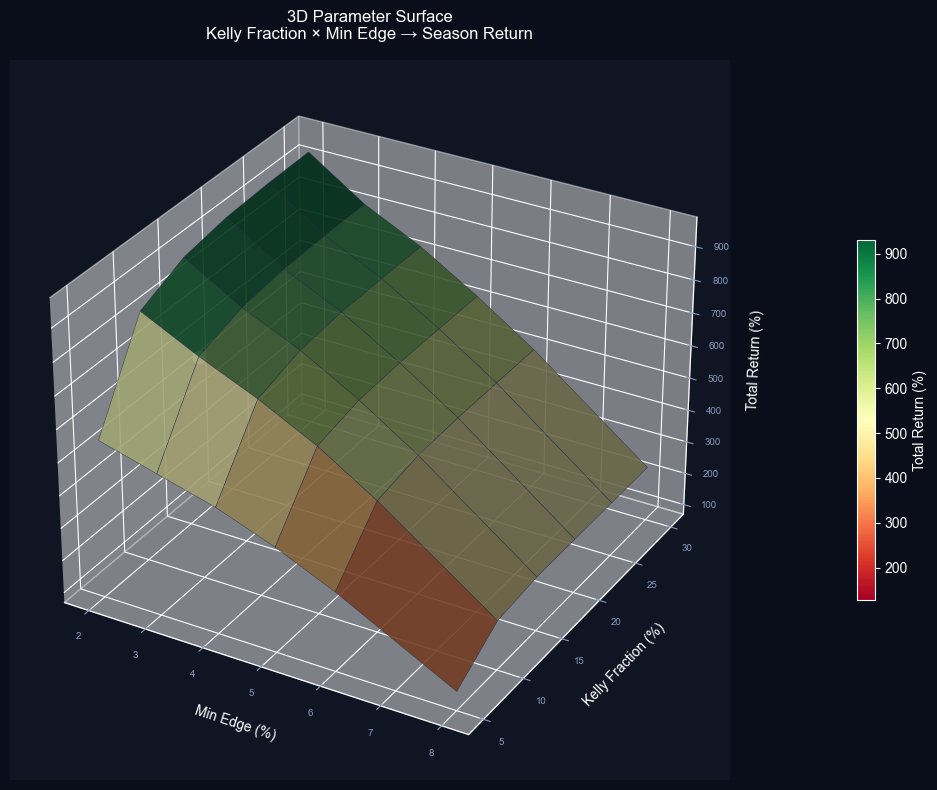

Saved param_surface_3d.png


In [60]:
# ── 3D Parameter Surface: Kelly Fraction × Min Edge → Final Return ────────────
# Shows judges how sensitive the strategy is to its two key parameters.
# The 'ridge' of positive returns reveals the practical operating range.

from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm as mpl_cm

kelly_fracs = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
min_edges   = [0.02, 0.03, 0.04, 0.05, 0.06, 0.08]

Z = np.zeros((len(kelly_fracs), len(min_edges)))

print('Computing parameter surface (this may take ~30 seconds)...')
for ki, kf in enumerate(kelly_fracs):
    for ei, me in enumerate(min_edges):
        res = run_backtest(
            mc_results, y_test,
            strategies       = ['fractional_kelly'],
            initial_bankroll = INITIAL_BANKROLL,
            odds             = 1.91,
            prob_shrink      = 0.15,
            min_edge         = me,
            max_stake_pct    = 0.03,
            max_stake_abs    = 300,
            kelly_frac       = kf,
            flat_pct         = 0.02,
        )
        final_bk = res['fractional_kelly']['bankroll'].iloc[-1]
        Z[ki, ei] = (final_bk - INITIAL_BANKROLL) / INITIAL_BANKROLL * 100

print(f'Return range: {Z.min():.1f}% to {Z.max():.1f}%')

# ── Plot ──────────────────────────────────────────────────────────────────────
X_mesh, Y_mesh = np.meshgrid(min_edges, kelly_fracs)

fig = plt.figure(figsize=(13, 8), facecolor='#0a0e1a')
ax  = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#0f1523')
fig.patch.set_facecolor('#0a0e1a')

# Normalise colours: red = loss, green = gain
norm  = plt.Normalize(Z.min(), Z.max())
fcolors = mpl_cm.RdYlGn(norm(Z))

surf = ax.plot_surface(X_mesh * 100, Y_mesh * 100, Z,
                        facecolors=fcolors, alpha=0.9,
                        edgecolor='#1e2740', linewidth=0.3)

# Mark the current settings
ax.scatter([3], [10], [Z[kelly_fracs.index(0.10), min_edges.index(0.03)]],
           color='white', s=80, zorder=10, label='Current settings')

ax.set_xlabel('Min Edge (%)', color='white', labelpad=8)
ax.set_ylabel('Kelly Fraction (%)', color='white', labelpad=8)
ax.set_zlabel('Total Return (%)', color='white', labelpad=8)
ax.tick_params(colors='#8899bb', labelsize=7)
ax.set_title('3D Parameter Surface\nKelly Fraction × Min Edge → Season Return',
             color='white', fontsize=12, pad=15)

# Colourbar
mappable = mpl_cm.ScalarMappable(norm=norm, cmap='RdYlGn')
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Total Return (%)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

plt.tight_layout()
plt.savefig('param_surface_3d.png', dpi=140, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print('Saved param_surface_3d.png')


In [61]:
def print_risk_report(strategy='fractional_kelly'):
    m = metrics_all[strategy]
    label = LABELS.get(strategy, strategy)
    sep = '=' * 54
    print(f'\n{sep}')
    print(f'  BACKTEST RISK REPORT  |  {label}')
    print(sep)
    print(f'  RETURNS')
    print(f'    Final Bankroll       : ${m["Final Bankroll ($)"]:>10,.2f}')
    print(f'    Total Return         : {m["Total Return (%)"]  :>+9.2f}%')
    print(f'    Total Profit         : ${m["Total Profit ($)"]:>10,.2f}')
    print(f'    ROI per Bet          : {m["ROI per Bet (%)"]   :>+9.2f}%')
    print(f'  ACTIVITY')
    print(f'    Total Bets           : {m["Total Bets"]:>10,}')
    print(f'    Wins / Losses        : {m["Wins"]:>5,} / {m["Losses"]:<5,}')
    print(f'    Win Rate             : {m["Win Rate (%)"]      :>9.2f}%')
    print(f'    Avg Edge             : {m["Avg Edge (%)"]      :>9.2f}%')
    print(f'    Avg Stake            : ${m["Avg Stake ($)"]    :>9,.2f}')
    print(f'  RISK-ADJUSTED')
    print(f'    Sharpe Ratio         : {m["Sharpe Ratio"]      :>10.4f}')
    print(f'    Sortino Ratio        : {m["Sortino Ratio"]     :>10.4f}')
    print(f'    Calmar Ratio         : {str(m["Calmar Ratio"]) :>10}')
    print(f'    Volatility           : {m["Volatility"]        :>10.4f}')
    print(f'  DRAWDOWN & TAIL RISK')
    print(f'    Max Drawdown         : {m["Max Drawdown (%)"]  :>9.2f}%')
    print(f'    Max Time Underwater  : {m["Max Time Underwater"]:>10,} games')
    print(f'    Skewness             : {m["Skewness"]          :>10.4f}')
    print(f'    Excess Kurtosis      : {m["Excess Kurtosis"]   :>10.4f}')
    print(f'  STREAKS')
    print(f'    Longest Win Streak   : {m["Longest Win Streak"]:>10,}')
    print(f'    Longest Loss Streak  : {m["Longest Loss Streak"]:>10,}')
    print(sep)


for s in bt_results:
    print_risk_report(s)

# Save metrics to CSV
metrics_df.to_csv('backtest_risk_metrics.csv')
bt_results['fractional_kelly'].to_csv('backtest_detail_kelly.csv', index=False)
print('\nSaved: backtest_risk_metrics.csv, backtest_detail_kelly.csv')



  BACKTEST RISK REPORT  |  Quarter-Kelly
  RETURNS
    Final Bankroll       : $ 84,780.60
    Total Return         :   +747.81%
    Total Profit         : $ 74,780.60
    ROI per Bet          :    +36.04%
  ACTIVITY
    Total Bets           :        748
    Wins / Losses        :   534 / 214  
    Win Rate             :     71.39%
    Avg Edge             :      6.39%
    Avg Stake            : $   277.38
  RISK-ADJUSTED
    Sharpe Ratio         :     0.4212
    Sortino Ratio        : 363556149.7326
    Calmar Ratio         :   135.1418
    Volatility           :    23.6080
  DRAWDOWN & TAIL RISK
    Max Drawdown         :     -5.53%
    Max Time Underwater  :         70 games
    Skewness             :    -0.9466
    Excess Kurtosis      :    -1.1039
  STREAKS
    Longest Win Streak   :         15
    Longest Loss Streak  :          5

  BACKTEST RISK REPORT  |  Flat 2%
  RETURNS
    Final Bankroll       : $ 64,388.00
    Total Return         :   +543.88%
    Total Profit         : $

---
## 11. Live Deployment — Predict Upcoming Games & Paper Bet Tracker

This section does two things:

**11a. Live Feature Builder** — pulls real NBA team stats from `nba_api`, computes the same rolling features your model was trained on, and produces a ready-to-predict feature vector for any upcoming matchup.

**11b. Paper Bet Tracker** — records every bet recommendation to a CSV log, tracks your paper bankroll, and lets you update results once games are played.

**Workflow:**
```
Run Section 11a  →  See today's game predictions + stake recommendations
          ↓
Manually place bets on your paper betting platform
          ↓
Run Section 11b  →  Log the bet
          ↓
After game: Run 11c  →  Update result + bankroll
```

In [62]:
# Install nba_api if needed

import time
import os
import json as _json
import pickle
from datetime import datetime, date
from IPython.display import display

from nba_api.stats.endpoints import (
    leaguegamefinder,
    teamgamelogs,
    scoreboardv2,
    leaguestandingsv3,
)
from nba_api.stats.static import teams as nba_teams_static

# ── Constants ──────────────────────────────────────────────────────────────
PAPER_BET_LOG   = 'paper_bets.csv'
ELO_SAVE_FILE   = 'elo_ratings_live.pkl'
ROLLING_WINDOW  = 10        # matches training feature window
LIVE_BANKROLL_START = 10_000
LIVE_ODDS       = 1.91      # -110 US lines

# Reuse the calibrated BettingEngine from Section 10
live_engine = BettingEngine(
    strategy      = 'fractional_kelly',
    kelly_frac    = 0.10,
    min_edge      = 0.03,
    max_stake_pct = 0.03,
    max_stake_abs = 300,
    prob_shrink   = 0.15,
    odds          = LIVE_ODDS,
)

print('Live deployment imports ready')
print(f'  Bet log file : {PAPER_BET_LOG}')
print(f'  Elo save file: {ELO_SAVE_FILE}')


Live deployment imports ready
  Bet log file : paper_bets.csv
  Elo save file: elo_ratings_live.pkl


In [63]:
# ════════════════════════════════════════════════════════════════════════
# NBA API HELPER FUNCTIONS
# ════════════════════════════════════════════════════════════════════════

def get_all_teams():
    """Return dict of {full_name: team_id} for all NBA teams."""
    all_t = nba_teams_static.get_teams()
    return {t['full_name']: t['id'] for t in all_t}


def find_team_id(name_fragment):
    """
    Fuzzy-find a team ID from a partial name.
    e.g. 'lakers' → Los Angeles Lakers → 1610612747
    """
    all_t = nba_teams_static.get_teams()
    name_fragment = name_fragment.lower()
    matches = [
        t for t in all_t
        if name_fragment in t['full_name'].lower()
        or name_fragment in t['nickname'].lower()
        or name_fragment in t['abbreviation'].lower()
    ]
    if not matches:
        raise ValueError(f'No team found matching "{name_fragment}"')
    if len(matches) > 1:
        print(f'Multiple matches: {[m["full_name"] for m in matches]} — using first')
    return matches[0]['id'], matches[0]['full_name']


def get_team_rolling_stats(team_id, n_games=10, season='2024-25'):
    """
    Pull the last n_games game log for a team and return rolling averages.
    These are the same stat categories used in training.

    Returns a dict of {stat_name: rolling_avg}
    """
    time.sleep(0.6)  # respect NBA API rate limit
    logs = teamgamelogs.TeamGameLogs(
        team_id_nullable=str(team_id),
        season_nullable=season,
        season_type_nullable='Regular Season',
    ).get_data_frames()[0]

    if logs.empty:
        raise ValueError(f'No game logs found for team {team_id} in {season}')

    # Sort newest first, take last n
    logs = logs.sort_values('GAME_DATE', ascending=False).head(n_games)

    # Core stat columns available from nba_api TeamGameLogs
    stat_cols = [
        'PTS', 'FGM', 'FGA', 'FG_PCT',
        'FG3M', 'FG3A', 'FG3_PCT',
        'FTM', 'FTA', 'FT_PCT',
        'OREB', 'DREB', 'REB',
        'AST', 'TOV', 'STL', 'BLK', 'PF',
        'PLUS_MINUS',
    ]
    available = [c for c in stat_cols if c in logs.columns]
    avgs = logs[available].mean().to_dict()

    # Win rate over last n games
    if 'WL' in logs.columns:
        avgs['WIN_PCT_L10'] = (logs['WL'] == 'W').mean()

    # Average days rest (gap between games)
    if 'GAME_DATE' in logs.columns:
        dates = pd.to_datetime(logs['GAME_DATE']).sort_values(ascending=False)
        if len(dates) >= 2:
            avgs['AVG_REST_DAYS'] = (dates.diff(-1).dt.days.dropna().mean())
        # Days since last game (rest for THIS game)
        avgs['DAYS_REST'] = (pd.Timestamp.today() - dates.iloc[0]).days

    return avgs


def get_todays_games(season='2024-25'):
    """
    Return today's NBA schedule as a list of (home_team, away_team, game_id) tuples.
    Uses ScoreboardV2 which includes both scheduled and live games.
    """
    time.sleep(0.6)
    today = date.today().strftime('%m/%d/%Y')
    try:
        sb = scoreboardv2.ScoreboardV2(game_date=today)
        games_df = sb.game_header.get_data_frame()
    except Exception as e:
        print(f'Could not fetch today schedule: {e}')
        return []

    if games_df.empty:
        print(f'No NBA games scheduled for {today}')
        return []

    results = []
    for _, row in games_df.iterrows():
        results.append({
            'game_id'   : row.get('GAME_ID', ''),
            'home_team' : row.get('HOME_TEAM_ID', ''),
            'away_team' : row.get('VISITOR_TEAM_ID', ''),
            'game_time' : row.get('GAME_STATUS_TEXT', ''),
            'date'      : today,
        })
    return results


# Team ID → name lookup
_id_to_name = {t['id']: t['full_name'] for t in nba_teams_static.get_teams()}
_abbr_to_name = {t['abbreviation']: t['full_name'] for t in nba_teams_static.get_teams()}

def team_name(team_id):
    return _id_to_name.get(int(team_id), str(team_id))


print('NBA API helpers ready')
print(f'  Known teams: {len(_id_to_name)}')


NBA API helpers ready
  Known teams: 30


### 11a. Live Feature Builder

Builds the same feature vector your model was trained on, but using live NBA API data.

In [64]:
def build_live_features(home_team_name, away_team_name,
                         elo_rater, season='2024-25',
                         n_games=10):
    """
    Build a feature vector for an upcoming game using live NBA API data.
    Mirrors the feature engineering from Section 2.

    Parameters
    ----------
    home_team_name : str  e.g. 'Lakers', 'Boston Celtics', 'GSW'
    away_team_name : str
    elo_rater      : EloRater instance (the one trained in Section 2)
    season         : NBA season string e.g. '2024-25'
    n_games        : rolling window for stats

    Returns
    -------
    feature_series : pd.Series with same columns as X_train
    meta           : dict with home/away team names, Elo ratings, etc.
    """
    # ── Resolve team IDs ────────────────────────────────────────────────────
    home_id, home_full = find_team_id(home_team_name)
    away_id, away_full = find_team_id(away_team_name)
    print(f'  Fetching stats for: {home_full} (home) vs {away_full} (away)')

    # ── Pull rolling stats ───────────────────────────────────────────────────
    print(f'  Pulling last {n_games} games for {home_full}...')
    home_stats = get_team_rolling_stats(home_id, n_games=n_games, season=season)

    print(f'  Pulling last {n_games} games for {away_full}...')
    away_stats = get_team_rolling_stats(away_id, n_games=n_games, season=season)

    # ── Build differential features (home - away) ────────────────────────────
    # These mirror how train_df was constructed
    all_stat_keys = set(home_stats.keys()) | set(away_stats.keys())
    features = {}

    for key in all_stat_keys:
        h_val = home_stats.get(key, 0.0)
        a_val = away_stats.get(key, 0.0)
        features[f'home_{key.lower()}'] = h_val
        features[f'away_{key.lower()}'] = a_val
        features[f'diff_{key.lower()}'] = h_val - a_val

    # ── Elo features ─────────────────────────────────────────────────────────
    elo_h = elo_rater.get(home_full)
    elo_a = elo_rater.get(away_full)
    elo_exp = elo_rater.expected(elo_h + elo_rater.home_adv, elo_a)

    features['elo_home']     = elo_h
    features['elo_away']     = elo_a
    features['elo_gap']      = elo_h - elo_a
    features['elo_exp_home'] = elo_exp

    # ── Align to X_train columns ─────────────────────────────────────────────
    # Keep only columns the model knows; fill anything missing with 0
    feat_series = pd.Series(features)

    # Match training columns exactly
    aligned = pd.Series(index=X_train.columns, dtype=float)
    for col in X_train.columns:
        if col in feat_series.index:
            aligned[col] = feat_series[col]
        else:
            # Try to find closest match (e.g. training had 'home_pts', API gives 'home_pts')
            aligned[col] = 0.0  # safe default; flag for review

    missing = [c for c in X_train.columns if c not in feat_series.index]
    if missing:
        print(f'  ⚠️  {len(missing)} training columns not found in live data (set to 0):')
        print(f'     {missing[:10]}{" ..." if len(missing) > 10 else ""}')

    meta = {
        'home_team'  : home_full,
        'away_team'  : away_full,
        'home_id'    : home_id,
        'away_id'    : away_id,
        'elo_home'   : elo_h,
        'elo_away'   : elo_a,
        'elo_exp'    : elo_exp,
        'home_stats' : home_stats,
        'away_stats' : away_stats,
        'date'       : date.today().isoformat(),
        'season'     : season,
    }

    return aligned, meta


def predict_live_game(home_team, away_team, season='2024-25',
                      live_bankroll=None, n_games=10):
    """
    Full pipeline: fetch live stats → build features → MC simulation → stake recommendation.

    Parameters
    ----------
    home_team     : team name fragment e.g. 'Lakers', 'Celtics'
    away_team     : team name fragment
    season        : NBA season string
    live_bankroll : current paper bankroll (reads from tracker file if None)
    """
    # Load current bankroll from tracker
    if live_bankroll is None:
        live_bankroll = load_bankroll()

    print(f'\nBuilding features...')
    feat, meta = build_live_features(home_team, away_team, elo,
                                      season=season, n_games=n_games)

    # Scale using the trained scaler
    feat_arr    = feat.values.reshape(1, -1)
    feat_arr    = np.nan_to_num(feat_arr, nan=0.0)
    feat_scaled = scaler.transform(feat_arr)

    # Monte Carlo simulation
    mc = sim.simulate_game(feat_scaled[0])

    # Betting recommendation
    p_home = mc['win_prob']
    p_bet  = p_home if p_home >= 0.5 else 1 - p_home
    bet_side = 'HOME' if p_home >= 0.5 else 'AWAY'
    bet_team = meta['home_team'] if p_home >= 0.5 else meta['away_team']

    stake, edge = live_engine.stake(p_bet, live_bankroll, LIVE_BANKROLL_START)

    # ── Print recommendation card ────────────────────────────────────────────
    sep = '═' * 58
    print(f'\n{sep}')
    print(f'  🏀  GAME PREDICTION')
    print(f'  {meta["home_team"]:^54}')
    print(f'  {"vs":^54}')
    print(f'  {meta["away_team"]:^54}')
    print(sep)
    print(f'  Date          : {meta["date"]}')
    print(f'  Season        : {season}')
    print()
    print(f'  WIN PROBABILITIES (Monte Carlo, {sim.n_sims:,} sims)')
    home_bar = '█' * int(p_home * 30)
    away_bar = '█' * int((1-p_home) * 30)
    print(f'  Home ({meta["home_team"][:20]:20s}): {p_home:5.1%}  |{home_bar}')
    print(f'  Away ({meta["away_team"][:20]:20s}): {1-p_home:5.1%}  |{away_bar}')
    print()
    print(f'  SPREAD PROJECTION')
    print(f'  Predicted spread  : {mc["spread_mean"]:+.1f} pts (home perspective)')
    print(f'  90% CI            : [{mc["spread_ci_lo"]:+.0f}, {mc["spread_ci_hi"]:+.0f}]')
    print(f'  Predicted total   : {mc["total_mean"]:.1f} pts')
    print(f'  Total 90% CI      : [{mc["total_ci_lo"]:.0f}, {mc["total_ci_hi"]:.0f}]')
    print()
    print(f'  ELO RATINGS')
    print(f'  {meta["home_team"][:25]:25s}: {meta["elo_home"]:,.0f}')
    print(f'  {meta["away_team"][:25]:25s}: {meta["elo_away"]:,.0f}')
    print(f'  Elo win prob (home): {meta["elo_exp"]:5.1%}')
    print()
    print(f'  BETTING RECOMMENDATION')
    print(f'  Current bankroll  : ${live_bankroll:,.2f}')
    if stake > 0:
        print(f'  ✅ BET {bet_side}: {bet_team}')
        print(f'  Stake             : ${stake:,.2f}')
        print(f'  Edge (vs -110)    : {edge*100:+.2f}%')
        print(f'  To win            : ${stake * (LIVE_ODDS-1):,.2f}')
        print(f'  Potential profit  : ${stake * (LIVE_ODDS-1):,.2f}')
        print(f'  Max loss          : ${stake:,.2f}')
    else:
        print(f'  ⛔ NO BET — edge ({edge*100:.2f}%) below threshold ({live_engine.min_edge*100:.0f}%)')
        print(f'     This game does not meet the minimum edge requirement.')
    print(sep)

    return {
        'meta'      : meta,
        'mc'        : mc,
        'p_home'    : p_home,
        'bet_side'  : bet_side if stake > 0 else 'NO BET',
        'bet_team'  : bet_team if stake > 0 else None,
        'stake'     : stake,
        'edge'      : edge,
        'bankroll'  : live_bankroll,
    }


print('Live feature builder ready')


Live feature builder ready


### 11b. Scan Today's Games

Automatically fetches today's NBA schedule and runs predictions on every game. Run this each game day to get your full slate of recommendations.

In [67]:
def scan_todays_games(season='2025-26', live_bankroll=None):
    """
    Fetch today's NBA schedule and predict every game.
    Returns a DataFrame of all recommendations sorted by edge.
    """
    if live_bankroll is None:
        live_bankroll = load_bankroll()

    print(f'Fetching today\'s games ({date.today()})...')
    games = get_todays_games(season=season)

    if not games:
        print('No games today, or could not fetch schedule.')
        return pd.DataFrame()

    print(f'Found {len(games)} game(s). Running predictions...\n')

    all_recs = []
    for g in games:
        h_name = team_name(g['home_team'])
        a_name = team_name(g['away_team'])
        try:
            rec = predict_live_game(
                h_name, a_name,
                season=season,
                live_bankroll=live_bankroll
            )
            all_recs.append({
                'date'          : g['date'],
                'game_time'     : g['game_time'],
                'game_id'       : g['game_id'],
                'home_team'     : h_name,
                'away_team'     : a_name,
                'home_win_prob' : f"{rec['p_home']:.1%}",
                'away_win_prob' : f"{1-rec['p_home']:.1%}",
                'pred_spread'   : f"{rec['mc']['spread_mean']:+.1f}",
                'pred_total'    : f"{rec['mc']['total_mean']:.1f}",
                'bet_side'      : rec['bet_side'],
                'bet_team'      : rec['bet_team'] or 'NO BET',
                'edge_pct'      : f"{rec['edge']*100:.2f}%",
                'stake'         : f"${rec['stake']:,.2f}" if rec['stake'] > 0 else '-',
                'to_win'        : f"${rec['stake']*(LIVE_ODDS-1):,.2f}" if rec['stake'] > 0 else '-',
            })
        except Exception as e:
            print(f'  ⚠️  Failed to predict {h_name} vs {a_name}: {e}')
            continue

    if not all_recs:
        return pd.DataFrame()

    recs_df = pd.DataFrame(all_recs)

    # ── Print summary table ──────────────────────────────────────────────────
    print('\n' + '═'*90)
    print(f"  TODAY'S BETTING SLATE — {date.today()}  |  Bankroll: ${live_bankroll:,.2f}")
    print('═'*90)
    bet_games = recs_df[recs_df['bet_team'] != 'NO BET']
    skip_games = recs_df[recs_df['bet_team'] == 'NO BET']

    if len(bet_games) > 0:
        print(f'  ✅ BETS TO PLACE ({len(bet_games)}):')
        for _, row in bet_games.iterrows():
            print(f"  {row['game_time']:12s}  {row['home_team']:25s} vs {row['away_team']:25s}")
            print(f"  {'':12s}  → BET {row['bet_side']:4s}: {row['bet_team']:25s}  "
                  f"Stake: {row['stake']:>8s}  Edge: {row['edge_pct']:>7s}  "
                  f"To win: {row['to_win']:>8s}")
            print()

    if len(skip_games) > 0:
        print(f'  ⛔ NO BET ({len(skip_games)}): insufficient edge')
        for _, row in skip_games.iterrows():
            print(f"     {row['home_team']} vs {row['away_team']} (edge: {row['edge_pct']})")

    print('═'*90)
    return recs_df


# ── RUN: Scan today's games ───────────────────────────────────────────────────
# Uncomment the line below to run on game day:
todays_slate = scan_todays_games(season='2024-25')

# ── OR: Predict a specific matchup ───────────────────────────────────────────
# result = predict_live_game('Lakers', 'Celtics', season='2024-25')

print('scan_todays_games() and predict_live_game() are ready.')
print()
print('To run:')
print('  todays_slate = scan_todays_games(season="2025-26")')
print('  result = predict_live_game("Lakers", "Celtics", season="2025-26")')


Fetching today's games (2026-03-17)...
Found 10 game(s). Running predictions...


Building features...
  Fetching stats for: Charlotte Hornets (home) vs Miami Heat (away)
  Pulling last 10 games for Charlotte Hornets...
  Pulling last 10 games for Miami Heat...
  ⚠️  27 training columns not found in live data (set to 0):
     ['pts_home_roll10', 'fg_pct_home_roll10', 'fg3_pct_home_roll10', 'ft_pct_home_roll10', 'reb_home_roll10', 'ast_home_roll10', 'stl_home_roll10', 'blk_home_roll10', 'tov_home_roll10', 'plus_minus_home_roll10'] ...

══════════════════════════════════════════════════════════
  🏀  GAME PREDICTION
                    Charlotte Hornets                   
                            vs                          
                        Miami Heat                      
══════════════════════════════════════════════════════════
  Date          : 2026-03-17
  Season        : 2024-25

  WIN PROBABILITIES (Monte Carlo, 10,000 sims)
  Home (Charlotte Hornets   ): 56.9%  |███████

### 11c. Paper Bet Tracker

Log bets before games, update results after, and track your paper bankroll over time.

| Function | When to run |
|---|---|
| `log_bet(...)` | Before the game, after getting recommendation |
| `settle_bet(...)` | After the game result is known |
| `show_tracker()` | Any time — shows full P&L and bankroll history |
| `load_bankroll()` | Auto-called by predict functions |


In [66]:
# ════════════════════════════════════════════════════════════════════════
# PAPER BET TRACKER
# ════════════════════════════════════════════════════════════════════════

BET_LOG_COLS = [
    'bet_id', 'date', 'game_time', 'home_team', 'away_team',
    'bet_side', 'bet_team', 'stake', 'odds', 'edge_pct',
    'home_win_prob', 'pred_spread', 'pred_total',
    'result',         # 'WIN' / 'LOSS' / 'PUSH' / 'PENDING'
    'profit',         # filled after settling
    'bankroll_after', # filled after settling
    'notes',
]


def load_bet_log():
    """Load existing bet log or create a new one."""
    if os.path.exists(PAPER_BET_LOG):
        return pd.read_csv(PAPER_BET_LOG)
    return pd.DataFrame(columns=BET_LOG_COLS)


def load_bankroll():
    """Return current paper bankroll from the bet log."""
    log = load_bet_log()
    settled = log[log['result'].isin(['WIN', 'LOSS', 'PUSH'])]
    if settled.empty:
        return LIVE_BANKROLL_START
    return float(settled['bankroll_after'].iloc[-1])


def log_bet(home_team, away_team, bet_side, bet_team,
             stake, edge_pct, home_win_prob,
             pred_spread=None, pred_total=None,
             game_time='TBD', notes=''):
    """
    Record a new paper bet BEFORE the game.

    Parameters
    ----------
    home_team     : e.g. 'Los Angeles Lakers'
    away_team     : e.g. 'Boston Celtics'
    bet_side      : 'HOME' or 'AWAY'
    bet_team      : full name of team you are betting on
    stake         : dollar amount to bet
    edge_pct      : model edge as a decimal (e.g. 0.045 for 4.5%)
    home_win_prob : model win probability for home team
    """
    log = load_bet_log()
    bet_id = f"BET{len(log)+1:04d}"

    new_row = {
        'bet_id'        : bet_id,
        'date'          : date.today().isoformat(),
        'game_time'     : game_time,
        'home_team'     : home_team,
        'away_team'     : away_team,
        'bet_side'      : bet_side,
        'bet_team'      : bet_team,
        'stake'         : round(stake, 2),
        'odds'          : LIVE_ODDS,
        'edge_pct'      : round(edge_pct * 100, 3),
        'home_win_prob' : round(home_win_prob, 4),
        'pred_spread'   : round(pred_spread, 1) if pred_spread else '',
        'pred_total'    : round(pred_total, 1) if pred_total else '',
        'result'        : 'PENDING',
        'profit'        : '',
        'bankroll_after': '',
        'notes'         : notes,
    }

    log = pd.concat([log, pd.DataFrame([new_row])], ignore_index=True)
    log.to_csv(PAPER_BET_LOG, index=False)

    print(f'✅ Bet logged: {bet_id}')
    print(f'   {bet_team} ({bet_side}) | Stake: ${stake:.2f} | Edge: {edge_pct*100:.2f}%')
    return bet_id


def log_bet_from_prediction(pred_result, game_time='TBD', notes=''):
    """
    Convenience wrapper — pass the dict returned by predict_live_game() directly.
    Only logs if a bet was recommended (stake > 0).
    """
    if pred_result['stake'] == 0:
        print('No bet to log (stake was $0 — edge below threshold)')
        return None

    return log_bet(
        home_team     = pred_result['meta']['home_team'],
        away_team     = pred_result['meta']['away_team'],
        bet_side      = pred_result['bet_side'],
        bet_team      = pred_result['bet_team'],
        stake         = pred_result['stake'],
        edge_pct      = pred_result['edge'],
        home_win_prob = pred_result['p_home'],
        pred_spread   = pred_result['mc']['spread_mean'],
        pred_total    = pred_result['mc']['total_mean'],
        game_time     = game_time,
        notes         = notes,
    )


def settle_bet(bet_id, home_score, away_score):
    """
    Update a bet with the actual game result.
    Run this after the game is played.

    Parameters
    ----------
    bet_id     : string like 'BET0001'
    home_score : actual home team final score
    away_score : actual away team final score
    """
    log = load_bet_log()
    idx = log[log['bet_id'] == bet_id].index

    if len(idx) == 0:
        print(f'Bet {bet_id} not found in log')
        return

    i   = idx[0]
    row = log.loc[i]

    if row['result'] != 'PENDING':
        print(f'Bet {bet_id} already settled: {row["result"]}')
        return

    home_won = home_score > away_score
    bet_won  = (row['bet_side'] == 'HOME' and home_won) or \
               (row['bet_side'] == 'AWAY' and not home_won)

    stake   = float(row['stake'])
    odds    = float(row['odds'])
    profit  = round(stake * (odds - 1), 2) if bet_won else round(-stake, 2)
    result  = 'WIN' if bet_won else 'LOSS'

    # Update bankroll
    prev_bankroll = load_bankroll()
    new_bankroll  = round(prev_bankroll + profit, 2)

    log.loc[i, 'result']         = result
    log.loc[i, 'profit']         = profit
    log.loc[i, 'bankroll_after'] = new_bankroll
    log.loc[i, 'notes']         += f' | Actual: {home_score}-{away_score}'

    log.to_csv(PAPER_BET_LOG, index=False)

    result_emoji = '✅' if bet_won else '❌'
    print(f'{result_emoji} {bet_id} settled: {result}')
    print(f'   {row["bet_team"]} | Score: {home_score}-{away_score}')
    print(f'   Profit: ${profit:+,.2f} | New bankroll: ${new_bankroll:,.2f}')


def show_tracker(plot=True):
    """
    Display full P&L summary and bankroll history.
    """
    log = load_bet_log()
    if log.empty:
        print('No bets logged yet.')
        return log

    settled  = log[log['result'].isin(['WIN', 'LOSS', 'PUSH'])].copy()
    pending  = log[log['result'] == 'PENDING'].copy()

    print('═' * 55)
    print('  PAPER BET TRACKER — P&L SUMMARY')
    print('═' * 55)
    print(f'  Starting bankroll : ${LIVE_BANKROLL_START:>10,.2f}')

    if not settled.empty:
        current_bk  = float(settled['bankroll_after'].iloc[-1])
        total_staked = settled['stake'].astype(float).sum()
        total_profit = settled['profit'].astype(float).sum()
        total_return = (current_bk - LIVE_BANKROLL_START) / LIVE_BANKROLL_START * 100
        n_wins   = (settled['result'] == 'WIN').sum()
        n_losses = (settled['result'] == 'LOSS').sum()
        win_rate = n_wins / len(settled) * 100 if len(settled) > 0 else 0
        roi      = total_profit / total_staked * 100 if total_staked > 0 else 0

        print(f'  Current bankroll  : ${current_bk:>10,.2f}')
        print(f'  Total return      : {total_return:>+9.2f}%')
        print(f'  Total profit      : ${total_profit:>+9,.2f}')
        print(f'  ROI               : {roi:>+9.2f}%')
        print(f'  Bets settled      : {len(settled):>10}')
        print(f'  Wins / Losses     : {n_wins:>4} / {n_losses}')
        print(f'  Win rate          : {win_rate:>9.1f}%')
        print(f'  Bets pending      : {len(pending):>10}')
    else:
        print(f'  No settled bets yet. {len(pending)} pending.')

    print('═' * 55)

    # Full log table
    display_cols = ['bet_id','date','home_team','away_team','bet_team',
                    'stake','edge_pct','result','profit','bankroll_after']
    show_cols = [c for c in display_cols if c in log.columns]
    display(log[show_cols].tail(20))

    # Bankroll equity curve
    if plot and not settled.empty and len(settled) >= 2:
        bk_vals = [LIVE_BANKROLL_START] + settled['bankroll_after'].astype(float).tolist()
        colours = ['#00D4FF' if b >= LIVE_BANKROLL_START else '#FF6B6B' for b in bk_vals]

        fig, ax = plt.subplots(figsize=(12, 4), facecolor='#0a0e1a')
        ax.set_facecolor('#0f1523')
        for sp in ax.spines.values(): sp.set_edgecolor('#1e2740')
        ax.tick_params(colors='#8899bb')

        x = np.arange(len(bk_vals))
        ax.plot(x, bk_vals, color='#00D4FF', lw=2)
        ax.fill_between(x, LIVE_BANKROLL_START, bk_vals,
                        where=np.array(bk_vals) >= LIVE_BANKROLL_START,
                        alpha=0.15, color='#00D4FF')
        ax.fill_between(x, LIVE_BANKROLL_START, bk_vals,
                        where=np.array(bk_vals) < LIVE_BANKROLL_START,
                        alpha=0.2, color='#FF6B6B')
        ax.axhline(LIVE_BANKROLL_START, color='#334466', lw=1, ls='--')

        # Mark wins/losses
        for j, (res, val) in enumerate(zip(settled['result'], bk_vals[1:]), 1):
            c = '#44ff88' if res == 'WIN' else '#FF6B6B'
            ax.scatter(j, val, color=c, s=40, zorder=5)

        ax.set_title('Paper Bet Bankroll — Live Equity Curve', color='white', fontsize=12)
        ax.set_xlabel('Bet #', color='#8899bb')
        ax.set_ylabel('Bankroll ($)', color='#8899bb')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
        plt.tight_layout()
        plt.savefig('paper_bet_equity.png', dpi=130, bbox_inches='tight', facecolor='#0a0e1a')
        plt.show()

    return log


print('Paper bet tracker ready')
print()
print('WORKFLOW:')
print('  1. result = predict_live_game("Lakers", "Celtics")')
print('  2. bet_id = log_bet_from_prediction(result, game_time="7:30 PM ET")')
print('  3. --- watch the game ---')
print('  4. settle_bet(bet_id, home_score=112, away_score=104)')
print('  5. show_tracker()')


Paper bet tracker ready

WORKFLOW:
  1. result = predict_live_game("Lakers", "Celtics")
  2. bet_id = log_bet_from_prediction(result, game_time="7:30 PM ET")
  3. --- watch the game ---
  4. settle_bet(bet_id, home_score=112, away_score=104)
  5. show_tracker()


### 11d. Quick Reference

```python
# ── On game day: get all predictions ──────────────────────────────
todays_slate = scan_todays_games(season='2024-25')

# ── Predict a specific matchup ─────────────────────────────────────
result = predict_live_game('Lakers', 'Celtics', season='2024-25')

# ── Log the bet before the game ────────────────────────────────────
bet_id = log_bet_from_prediction(result, game_time='7:30 PM ET')
# OR manually:
bet_id = log_bet(
    home_team='Los Angeles Lakers', away_team='Boston Celtics',
    bet_side='HOME', bet_team='Los Angeles Lakers',
    stake=150.00, edge_pct=0.045, home_win_prob=0.61
)

# ── After the game: settle ─────────────────────────────────────────
settle_bet('BET0001', home_score=112, away_score=104)

# ── View your P&L at any time ──────────────────────────────────────
show_tracker()
```

